# 1. PDF Text Extraction and Text Cleaning

This section extracts text from the 30 annual reports, checks whether the extracted text is usable, creates the main text dataset, and cleans the text for NLP analysis.

# Project Alignment Note

This notebook supports the dissertation research questions by combining three types of evidence:

1. **VADER sentiment analysis** measures how positive or negative the annual report language is.
2. **BERTopic topic modelling** identifies ESG-related disclosure themes automatically from text chunks.
3. **Environmental performance indicators** provide real company-year ESG evidence where the reports disclose usable values.

The analysis is exploratory because ESG data availability is inconsistent across companies and years. Therefore, the notebook identifies **greenwashing-risk indicators**, not legal proof of greenwashing.


In [13]:
import os
from pathlib import Path

base_dir = Path.cwd().parent

pdf_dir = base_dir / "01_reports_pdf"
text_dir = base_dir / "02_extracted_text"
data_dir = base_dir / "03_data_tracker"
output_dir = base_dir / "05_outputs"

print("Base folder:", base_dir)
print("PDF folder exists:", pdf_dir.exists())
print("Text folder exists:", text_dir.exists())
print("Number of PDFs:", len(list(pdf_dir.glob("*.pdf"))))

Base folder: C:\Users\umane\Downloads\Greenwashing_NLP_Dissertation
PDF folder exists: True
Text folder exists: True
Number of PDFs: 30


In [103]:
# Install PyMuPDF for PDF text extraction.
# Run this once if the package is not already installed.
%pip install pymupdf

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



In [15]:
import fitz  # PyMuPDF
from pathlib import Path

print("PyMuPDF imported successfully")

PyMuPDF imported successfully


In [16]:
import fitz
from pathlib import Path

base_dir = Path.cwd().parent

pdf_dir = base_dir / "01_reports_pdf"
text_dir = base_dir / "02_extracted_text"

text_dir.mkdir(exist_ok=True)

pdf_files = sorted(pdf_dir.glob("*.pdf"))

print(f"Found {len(pdf_files)} PDF files")

for pdf_file in pdf_files:
    print(f"Extracting: {pdf_file.name}")
    
    text_output = ""
    
    try:
        doc = fitz.open(pdf_file)
        
        for page_num, page in enumerate(doc, start=1):
            page_text = page.get_text()
            text_output += f"\n\n--- Page {page_num} ---\n\n"
            text_output += page_text
        
        doc.close()
        
        txt_file = text_dir / pdf_file.with_suffix(".txt").name
        
        with open(txt_file, "w", encoding="utf-8") as f:
            f.write(text_output)
        
        print(f"Saved: {txt_file.name}")
    
    except Exception as e:
        print(f"Error with {pdf_file.name}: {e}")

print("Text extraction complete.")

Found 30 PDF files
Extracting: ASOS_2019_Annual_Report.pdf
Saved: ASOS_2019_Annual_Report.txt
Extracting: ASOS_2020_Annual_Report.pdf
Saved: ASOS_2020_Annual_Report.txt
Extracting: ASOS_2021_Annual_Report.pdf
Saved: ASOS_2021_Annual_Report.txt
Extracting: ASOS_2022_Annual_Report.pdf
Saved: ASOS_2022_Annual_Report.txt
Extracting: ASOS_2023_Annual_Report.pdf
Saved: ASOS_2023_Annual_Report.txt
Extracting: ASOS_2024_Annual_Report.pdf
Saved: ASOS_2024_Annual_Report.txt
Extracting: BOOHOO_2019_Annual_Report.pdf
Saved: BOOHOO_2019_Annual_Report.txt
Extracting: BOOHOO_2020_Annual_Report.pdf
Saved: BOOHOO_2020_Annual_Report.txt
Extracting: BOOHOO_2021_Annual_Report.pdf
Saved: BOOHOO_2021_Annual_Report.txt
Extracting: BOOHOO_2022_Annual_Report.pdf
Saved: BOOHOO_2022_Annual_Report.txt
Extracting: BOOHOO_2023_Annual_Report.pdf
Saved: BOOHOO_2023_Annual_Report.txt
Extracting: BOOHOO_2024_Annual_Report.pdf
Saved: BOOHOO_2024_Annual_Report.txt
Extracting: JD_2019_Annual_Report.pdf
Saved: JD_2019_Annu

In [17]:
txt_files = sorted(text_dir.glob("*.txt"))

print("Number of text files:", len(txt_files))

for file in txt_files:
    print(file.name)

Number of text files: 30
ASOS_2019_Annual_Report.txt
ASOS_2020_Annual_Report.txt
ASOS_2021_Annual_Report.txt
ASOS_2022_Annual_Report.txt
ASOS_2023_Annual_Report.txt
ASOS_2024_Annual_Report.txt
BOOHOO_2019_Annual_Report.txt
BOOHOO_2020_Annual_Report.txt
BOOHOO_2021_Annual_Report.txt
BOOHOO_2022_Annual_Report.txt
BOOHOO_2023_Annual_Report.txt
BOOHOO_2024_Annual_Report.txt
JD_2019_Annual_Report.txt
JD_2020_Annual_Report.txt
JD_2021_Annual_Report.txt
JD_2022_Annual_Report.txt
JD_2023_Annual_Report.txt
JD_2024_Annual_Report.txt
MKS_2019_Annual_Report.txt
MKS_2020_Annual_Report.txt
MKS_2021_Annual_Report.txt
MKS_2022_Annual_Report.txt
MKS_2023_Annual_Report.txt
MKS_2024_Annual_Report.txt
NEXT_2019_Annual_Report.txt
NEXT_2020_Annual_Report.txt
NEXT_2021_Annual_Report.txt
NEXT_2022_Annual_Report.txt
NEXT_2023_Annual_Report.txt
NEXT_2024_Annual_Report.txt


In [18]:
from pathlib import Path
import pandas as pd

base_dir = Path.cwd().parent
text_dir = base_dir / "02_extracted_text"

txt_files = sorted(text_dir.glob("*.txt"))

text_check = []

for txt_file in txt_files:
    with open(txt_file, "r", encoding="utf-8", errors="ignore") as f:
        text = f.read()
    
    word_count = len(text.split())
    char_count = len(text)
    
    text_check.append({
        "file_name": txt_file.name,
        "word_count": word_count,
        "character_count": char_count,
        "status": "OK" if word_count > 1000 else "CHECK"
    })

text_check_df = pd.DataFrame(text_check)

text_check_df

,file_name,word_count,character_count,status
0,ASOS_2019_Annual_Report.txt,56619,363854,OK
1,ASOS_2020_Annual_Report.txt,65844,424525,OK
2,ASOS_2021_Annual_Report.txt,73738,475351,OK
3,ASOS_2022_Annual_Report.txt,96290,620305,OK
4,ASOS_2023_Annual_Report.txt,99804,647846,OK
5,ASOS_2024_Annual_Report.txt,101842,666561,OK
6,BOOHOO_2019_Annual_Report.txt,37311,247013,OK
7,BOOHOO_2020_Annual_Report.txt,44081,294838,OK
8,BOOHOO_2021_Annual_Report.txt,51706,333720,OK
9,BOOHOO_2022_Annual_Report.txt,60984,394795,OK


In [19]:
output_dir = base_dir / "05_outputs"
output_dir.mkdir(exist_ok=True)

text_check_df.to_csv(output_dir / "text_extraction_quality_check.csv", index=False)

print("Saved text quality check.")

Saved text quality check.


In [20]:
from pathlib import Path
import pandas as pd

base_dir = Path.cwd().parent
text_dir = base_dir / "02_extracted_text"
output_dir = base_dir / "05_outputs"

records = []

for txt_file in sorted(text_dir.glob("*.txt")):
    file_name = txt_file.name
    
    with open(txt_file, "r", encoding="utf-8", errors="ignore") as f:
        text = f.read()
    
    parts = file_name.replace(".txt", "").split("_")
    
    company_short = parts[0]
    year = int(parts[1])
    
    records.append({
        "company_short": company_short,
        "year": year,
        "file_name": file_name,
        "raw_text": text,
        "word_count": len(text.split()),
        "character_count": len(text)
    })

main_text_df = pd.DataFrame(records)

main_text_df.head()

,company_short,year,file_name,raw_text,word_count,character_count
0,ASOS,2019,ASOS_2019_Annual_Report.txt,\n\n--- Page 1 ---\n\nSTRATEGIC REPORT\nBuildi...,56619,363854
1,ASOS,2020,ASOS_2020_Annual_Report.txt,\n\n--- Page 1 ---\n\nAgile\nResilient\nStrong...,65844,424525
2,ASOS,2021,ASOS_2021_Annual_Report.txt,\n\n--- Page 1 ---\n\nASOS Plc Annual Report a...,73738,475351
3,ASOS,2022,ASOS_2022_Annual_Report.txt,\n\n--- Page 1 ---\n\nCHANGE\nDRIVING\nNOW\nAS...,96290,620305
4,ASOS,2023,ASOS_2023_Annual_Report.txt,\n\n--- Page 1 ---\n\nASOS Plc Annual Report a...,99804,647846


In [21]:
main_text_df.shape

(30, 6)

In [22]:
main_text_df.to_csv(output_dir / "main_text_dataset.csv", index=False)

print("Main text dataset saved.")

Main text dataset saved.


In [23]:
import re

def clean_text(text):
    text = str(text)
    
    # Remove page markers like --- Page 1 ---
    text = re.sub(r"--- Page \d+ ---", " ", text)
    
    # Remove extra spaces and line breaks
    text = re.sub(r"\s+", " ", text)
    
    # Remove strange characters but keep normal punctuation
    text = re.sub(r"[^\x00-\x7F]+", " ", text)
    
    # Strip leading/trailing spaces
    text = text.strip()
    
    return text

main_text_df["clean_text"] = main_text_df["raw_text"].apply(clean_text)

main_text_df["clean_word_count"] = main_text_df["clean_text"].apply(lambda x: len(x.split()))

main_text_df[["company_short", "year", "word_count", "clean_word_count"]].head()

,company_short,year,word_count,clean_word_count
0,ASOS,2019,56619,56113
1,ASOS,2020,65844,65185
2,ASOS,2021,73738,72928
3,ASOS,2022,96290,94828
4,ASOS,2023,99804,98213


In [24]:
main_text_df[["company_short", "year", "word_count", "clean_word_count"]]

,company_short,year,word_count,clean_word_count
0,ASOS,2019,56619,56113
1,ASOS,2020,65844,65185
2,ASOS,2021,73738,72928
3,ASOS,2022,96290,94828
4,ASOS,2023,99804,98213
5,ASOS,2024,101842,100236
6,BOOHOO,2019,37311,36505
7,BOOHOO,2020,44081,43329
8,BOOHOO,2021,51706,51232
9,BOOHOO,2022,60984,59887


In [25]:
main_text_df.to_csv(output_dir / "main_text_dataset_cleaned.csv", index=False)

print("Cleaned text dataset saved.")

Cleaned text dataset saved.


# 2. VADER Sentiment Analysis

This section applies VADER sentiment analysis to the cleaned annual report text. Because annual reports are long documents, the text is split into smaller chunks and average sentiment scores are calculated for each company-year report.

In [104]:
# Install VADER sentiment package.
# Run this once if the package is not already installed.
%pip install vaderSentiment

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



In [27]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

print("VADER imported successfully")

VADER imported successfully


Annual reports are long documents, so the text is divided into smaller chunks.
VADER is applied to each chunk, and the average score is used as the report-level sentiment score.

In [28]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import time
import numpy as np

analyzer = SentimentIntensityAnalyzer()

def chunk_text(text, chunk_size=5000):
    text = str(text)
    return [text[i:i+chunk_size] for i in range(0, len(text), chunk_size)]

def get_vader_scores_fast(text):
    chunks = chunk_text(text, chunk_size=5000)
    
    scores_list = []
    
    for chunk in chunks:
        if chunk.strip():
            scores_list.append(analyzer.polarity_scores(chunk))
    
    if len(scores_list) == 0:
        return {
            "neg": 0,
            "neu": 0,
            "pos": 0,
            "compound": 0
        }
    
    return {
        "neg": np.mean([s["neg"] for s in scores_list]),
        "neu": np.mean([s["neu"] for s in scores_list]),
        "pos": np.mean([s["pos"] for s in scores_list]),
        "compound": np.mean([s["compound"] for s in scores_list])
    }

vader_neg = []
vader_neu = []
vader_pos = []
vader_compound = []

start_time = time.time()

for index, row in main_text_df.iterrows():
    company = row["company_short"]
    year = row["year"]
    
    print(f"Processing {company} {year}...")
    
    scores = get_vader_scores_fast(row["clean_text"])
    
    vader_neg.append(scores["neg"])
    vader_neu.append(scores["neu"])
    vader_pos.append(scores["pos"])
    vader_compound.append(scores["compound"])

main_text_df["vader_neg"] = vader_neg
main_text_df["vader_neu"] = vader_neu
main_text_df["vader_pos"] = vader_pos
main_text_df["vader_compound"] = vader_compound

end_time = time.time()

print("VADER sentiment analysis complete.")
print("Time taken:", round(end_time - start_time, 2), "seconds")

main_text_df[[
    "company_short", 
    "year", 
    "vader_neg", 
    "vader_neu", 
    "vader_pos", 
    "vader_compound"
]]

Processing ASOS 2019...
Processing ASOS 2020...
Processing ASOS 2021...
Processing ASOS 2022...
Processing ASOS 2023...
Processing ASOS 2024...
Processing BOOHOO 2019...
Processing BOOHOO 2020...
Processing BOOHOO 2021...
Processing BOOHOO 2022...
Processing BOOHOO 2023...
Processing BOOHOO 2024...
Processing JD 2019...
Processing JD 2020...
Processing JD 2021...
Processing JD 2022...
Processing JD 2023...
Processing JD 2024...
Processing MKS 2019...
Processing MKS 2020...
Processing MKS 2021...
Processing MKS 2022...
Processing MKS 2023...
Processing MKS 2024...
Processing NEXT 2019...
Processing NEXT 2020...
Processing NEXT 2021...
Processing NEXT 2022...
Processing NEXT 2023...
Processing NEXT 2024...
VADER sentiment analysis complete.
Time taken: 80.12 seconds


,company_short,year,vader_neg,vader_neu,vader_pos,vader_compound
0,ASOS,2019,0.026583,0.845653,0.127806,0.988711
1,ASOS,2020,0.029917,0.843810,0.126298,0.941258
2,ASOS,2021,0.028628,0.850457,0.120883,0.879921
3,ASOS,2022,0.034393,0.853828,0.111877,0.840607
4,ASOS,2023,0.035693,0.855929,0.108394,0.843732
5,ASOS,2024,0.037191,0.854237,0.108580,0.795398
6,BOOHOO,2019,0.033229,0.845208,0.121625,0.903150
7,BOOHOO,2020,0.031964,0.843143,0.124839,0.850739
8,BOOHOO,2021,0.029697,0.839045,0.131348,0.852482
9,BOOHOO,2022,0.031692,0.842295,0.126038,0.820577


In [29]:
main_text_df.to_csv(output_dir / "main_text_dataset_with_vader.csv", index=False)

print("VADER sentiment dataset saved.")

VADER sentiment dataset saved.


In [30]:
vader_summary = main_text_df[[
    "company_short",
    "year",
    "word_count",
    "clean_word_count",
    "vader_neg",
    "vader_neu",
    "vader_pos",
    "vader_compound"
]].sort_values(["company_short", "year"])

vader_summary

,company_short,year,word_count,clean_word_count,vader_neg,vader_neu,vader_pos,vader_compound
0,ASOS,2019,56619,56113,0.026583,0.845653,0.127806,0.988711
1,ASOS,2020,65844,65185,0.029917,0.843810,0.126298,0.941258
2,ASOS,2021,73738,72928,0.028628,0.850457,0.120883,0.879921
3,ASOS,2022,96290,94828,0.034393,0.853828,0.111877,0.840607
4,ASOS,2023,99804,98213,0.035693,0.855929,0.108394,0.843732
5,ASOS,2024,101842,100236,0.037191,0.854237,0.108580,0.795398
6,BOOHOO,2019,37311,36505,0.033229,0.845208,0.121625,0.903150
7,BOOHOO,2020,44081,43329,0.031964,0.843143,0.124839,0.850739
8,BOOHOO,2021,51706,51232,0.029697,0.839045,0.131348,0.852482
9,BOOHOO,2022,60984,59887,0.031692,0.842295,0.126038,0.820577


In [31]:
vader_summary.to_csv(output_dir / "vader_sentiment_summary.csv", index=False)

print("VADER summary saved.")

VADER summary saved.


# 3. BERTopic Topic Modelling

This section applies BERTopic to the cleaned annual report text. Unlike manual keyword counting, BERTopic automatically identifies topics from the text using embeddings and clustering. The discovered topics will later be interpreted and compared with ESG/environmental performance data.


In [105]:
# Install CPU version of PyTorch for BERTopic dependencies.
# Run this once if the package is not already installed.
%pip install torch --index-url https://download.pytorch.org/whl/cpu
%pip install bertopic sentence-transformers umap-learn hdbscan

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cpu
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [33]:
#Import libraries
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP
from hdbscan import HDBSCAN

import pandas as pd
import numpy as np
import re
from pathlib import Path

In [35]:
# Create text chunks for BERTopic
# Each annual report is divided into smaller chunks so that BERTopic has enough documents to identify topics.

def split_text_into_chunks(text, chunk_size=700, min_words=150):
    words = str(text).split()
    chunks = []
    
    for i in range(0, len(words), chunk_size):
        chunk_words = words[i:i + chunk_size]
        
        if len(chunk_words) >= min_words:
            chunk = " ".join(chunk_words)
            chunks.append(chunk)
    
    return chunks


chunk_records = []

for index, row in main_text_df.iterrows():
    company = row["company_short"]
    year = row["year"]
    text = row["clean_text"]
    
    chunks = split_text_into_chunks(text, chunk_size=700, min_words=150)
    
    for chunk_id, chunk_text in enumerate(chunks, start=1):
        chunk_records.append({
            "company_short": company,
            "year": year,
            "chunk_id": chunk_id,
            "chunk_text": chunk_text,
            "chunk_word_count": len(chunk_text.split())
        })

bertopic_chunks_df = pd.DataFrame(chunk_records)

print("Number of text chunks created:", bertopic_chunks_df.shape[0])

bertopic_chunks_df.head()

Number of text chunks created: 4258


,company_short,year,chunk_id,chunk_text,chunk_word_count
0,ASOS,2019,1,STRATEGIC REPORT Building A Truly Global Retai...,700
1,ASOS,2019,2,difference. Find out more on pages 28 to 31. L...,700
2,ASOS,2019,3,I would like to thank every one of our ASOSers...,700
3,ASOS,2019,4,our global ambitions is also a key priority fo...,700
4,ASOS,2019,5,"the roll out of our clustered US sites, allowi...",700


In [36]:
#Save chunk dataset
bertopic_chunks_df.to_csv(output_dir / "bertopic_text_chunks.csv", index=False)

print("BERTopic text chunks saved.")

BERTopic text chunks saved.


In [39]:
# Run BERTopic
# Prepare documents for BERTopic
docs = bertopic_chunks_df["chunk_text"].tolist()

# Sentence transformer model for document embeddings
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# UMAP reduces embedding dimensions before clustering
umap_model = UMAP(
    n_neighbors=10,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

# HDBSCAN clusters similar text chunks into topics
hdbscan_model = HDBSCAN(
    min_cluster_size=20,
    min_samples=5,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

# CountVectorizer helps BERTopic generate readable topic words
vectorizer_model = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2
)

# Create BERTopic model
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    calculate_probabilities=True,
    verbose=True
)

# Fit BERTopic model
topics, probabilities = topic_model.fit_transform(docs)

print("BERTopic modelling complete.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

2026-08-24 22:45:22,902 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/134 [00:00<?, ?it/s]

2026-08-24 22:49:50,398 - BERTopic - Embedding - Completed ✓
2026-08-24 22:49:50,416 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-08-24 22:50:00,825 - BERTopic - Dimensionality - Completed ✓
2026-08-24 22:50:00,889 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-08-24 22:50:02,128 - BERTopic - Cluster - Completed ✓
2026-08-24 22:50:02,188 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-08-24 22:50:07,964 - BERTopic - Representation - Completed ✓


BERTopic modelling complete.


In [40]:
#Save BERTopic topic information
topic_info = topic_model.get_topic_info()

topic_info.to_csv(output_dir / "bertopic_topic_info.csv", index=False)

topic_info.head(20)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,664,-1_group_board_year_financial,"[group, board, year, financial, business, repo...",[2022 129 Notes to the Financial Statements co...
1,0,534,0_remuneration_performance_executive_committee,"[remuneration, performance, executive, committ...",[over the vesting period. Determining whether ...
2,1,162,1_impairment_assets_million_value,"[impairment, assets, million, value, group, as...",[the carrying value if the impairment had not ...
3,2,143,2_company_shares_resolution_authority,"[company, shares, resolution, authority, ordin...","[into agreements, which would, or might, requi..."
4,3,135,3_hedging_hedge_foreign_currency,"[hedging, hedge, foreign, currency, hedged, fa...",[hedged item used to determine hedge effective...
5,4,107,4_lease_leases_right use_payments,"[lease, leases, right use, payments, asset, ri...",[payable by the lessee under residual value gu...
6,5,100,5_sales_online_margin_jan,"[sales, online, margin, jan, year, growth, pri...",[more lower margin (but higher priced) third-p...
7,6,100,6_stores_jd_sports_fashion,"[stores, jd, sports, fashion, sports fashion, ...",[Plc Annual Report and Accounts 2023 Property ...
8,7,96,7_risk_risks_internal_committee,"[risk, risks, internal, committee, management,...",[2024 13.4 14.5 2023 2024 163.4 170.5 2023 202...
9,8,83,8_tax_deferred tax_deferred_income,"[tax, deferred tax, deferred, income, share, r...",[55.7 138.3 Factors affecting the tax charge i...


In [38]:
#Add BERTopic results to chunk dataset
bertopic_chunks_df["bertopic_topic"] = topics

bertopic_chunks_df[[
    "company_short",
    "year",
    "chunk_id",
    "bertopic_topic",
    "chunk_word_count"
]].head()

,company_short,year,chunk_id,bertopic_topic,chunk_word_count
0,ASOS,2019,1,24,700
1,ASOS,2019,2,24,700
2,ASOS,2019,3,24,700
3,ASOS,2019,4,24,700
4,ASOS,2019,5,31,700


In [41]:
# Print topic keywords for interpretation & Display top words for each discovered topic
# These words help us manually label topics later in the dissertation.

for topic_id in topic_info["Topic"].head(15):
    if topic_id != -1:
        print("\nTopic", topic_id)
        print(topic_model.get_topic(topic_id))


Topic 0
[('remuneration', np.float64(0.022196649155235764)), ('performance', np.float64(0.01678758091531443)), ('executive', np.float64(0.016676564127896098)), ('committee', np.float64(0.01557282677255909)), ('bonus', np.float64(0.015361246860399828)), ('salary', np.float64(0.0149525428713594)), ('directors', np.float64(0.01487203399183393)), ('executive directors', np.float64(0.013286657703277171)), ('awards', np.float64(0.012368775503327349)), ('pay', np.float64(0.012191265117288207))]

Topic 1
[('impairment', np.float64(0.020138541570452452)), ('assets', np.float64(0.014759375592798782)), ('million', np.float64(0.013434756182417075)), ('value', np.float64(0.011739515048985044)), ('group', np.float64(0.009956892139147624)), ('assumptions', np.float64(0.009427645678992467)), ('acquisition', np.float64(0.009217010034687936)), ('goodwill', np.float64(0.009192665686587498)), ('period', np.float64(0.008881856946956682)), ('cash', np.float64(0.00866426213116936))]

Topic 2
[('company', np

In [42]:
# Save the BERTopic topic assigned to each text chunk
# This file shows which topic each chunk of each annual report belongs to

bertopic_chunks_df.to_csv(output_dir / "bertopic_chunk_level_results.csv", index=False)

print("Chunk-level BERTopic results saved.")

Chunk-level BERTopic results saved.


In [43]:
# Topic proportion analysis
# This calculates how much each company-year report talks about each BERTopic topic.
# Topic -1 means outlier/noise, so we remove it from the main topic proportion analysis.

valid_topic_chunks = bertopic_chunks_df[bertopic_chunks_df["bertopic_topic"] != -1].copy()

# Count how many chunks belong to each topic for each company-year
topic_counts = valid_topic_chunks.groupby([
    "company_short",
    "year",
    "bertopic_topic"
]).size().reset_index(name="topic_chunk_count")

# Count total valid chunks for each company-year
total_chunks = valid_topic_chunks.groupby([
    "company_short",
    "year"
]).size().reset_index(name="total_valid_chunks")

# Merge topic counts with total chunks
topic_proportions = topic_counts.merge(
    total_chunks,
    on=["company_short", "year"],
    how="left"
)

# Calculate topic proportion
topic_proportions["topic_proportion"] = (
    topic_proportions["topic_chunk_count"] / topic_proportions["total_valid_chunks"]
)

# Save long-format topic proportions
topic_proportions.to_csv(output_dir / "bertopic_topic_proportions_long.csv", index=False)

topic_proportions.head()

,company_short,year,bertopic_topic,topic_chunk_count,total_valid_chunks,topic_proportion
0,ASOS,2019,0,13,69,0.188406
1,ASOS,2019,1,1,69,0.014493
2,ASOS,2019,2,1,69,0.014493
3,ASOS,2019,3,5,69,0.072464
4,ASOS,2019,4,1,69,0.014493


In [44]:
# Create wide-format topic proportion table
# Each topic becomes a separate column.
# This format is easier to merge later with VADER sentiment and ESG data.

topic_proportions_wide = topic_proportions.pivot_table(
    index=["company_short", "year"],
    columns="bertopic_topic",
    values="topic_proportion",
    fill_value=0
).reset_index()

# Rename topic columns clearly
topic_proportions_wide.columns = [
    f"topic_{col}_proportion" if isinstance(col, int) else col
    for col in topic_proportions_wide.columns
]

# Save wide-format topic proportions
topic_proportions_wide.to_csv(output_dir / "bertopic_topic_proportions_wide.csv", index=False)

topic_proportions_wide.head()

,company_short,year,topic_0_proportion,topic_1_proportion,topic_2_proportion,topic_3_proportion,topic_4_proportion,topic_5_proportion,topic_6_proportion,topic_7_proportion,...,topic_51_proportion,topic_52_proportion,topic_53_proportion,topic_54_proportion,topic_55_proportion,topic_56_proportion,topic_57_proportion,topic_58_proportion,topic_59_proportion,topic_60_proportion
0,ASOS,2019,0.188406,0.014493,0.014493,0.072464,0.014493,0.028986,0.0,0.043478,...,0.000000,0.014493,0.014493,0.000000,0.000000,0.014493,0.000000,0.0,0.0,0.0
1,ASOS,2020,0.223684,0.000000,0.013158,0.039474,0.039474,0.039474,0.0,0.065789,...,0.000000,0.026316,0.013158,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
2,ASOS,2021,0.188889,0.044444,0.033333,0.033333,0.011111,0.033333,0.0,0.044444,...,0.000000,0.022222,0.000000,0.000000,0.011111,0.011111,0.000000,0.0,0.0,0.0
3,ASOS,2022,0.200000,0.018182,0.027273,0.027273,0.018182,0.027273,0.0,0.027273,...,0.000000,0.018182,0.009091,0.009091,0.000000,0.009091,0.009091,0.0,0.0,0.0
4,ASOS,2023,0.119658,0.017094,0.008547,0.025641,0.034188,0.025641,0.0,0.034188,...,0.008547,0.042735,0.017094,0.017094,0.000000,0.008547,0.000000,0.0,0.0,0.0


In [45]:
# Merge VADER sentiment results with BERTopic topic proportions
# This creates the main NLP dataset before ESG data is added.

vader_bertopic_df = vader_summary.merge(
    topic_proportions_wide,
    on=["company_short", "year"],
    how="left"
)

# Save combined VADER + BERTopic dataset
vader_bertopic_df.to_csv(output_dir / "vader_bertopic_combined_dataset.csv", index=False)

print("VADER + BERTopic combined dataset saved.")

vader_bertopic_df.head()

VADER + BERTopic combined dataset saved.


,company_short,year,word_count,clean_word_count,vader_neg,vader_neu,vader_pos,vader_compound,topic_0_proportion,topic_1_proportion,...,topic_51_proportion,topic_52_proportion,topic_53_proportion,topic_54_proportion,topic_55_proportion,topic_56_proportion,topic_57_proportion,topic_58_proportion,topic_59_proportion,topic_60_proportion
0,ASOS,2019,56619,56113,0.026583,0.845653,0.127806,0.988711,0.188406,0.014493,...,0.000000,0.014493,0.014493,0.000000,0.000000,0.014493,0.000000,0.0,0.0,0.0
1,ASOS,2020,65844,65185,0.029917,0.843810,0.126298,0.941258,0.223684,0.000000,...,0.000000,0.026316,0.013158,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
2,ASOS,2021,73738,72928,0.028628,0.850457,0.120883,0.879921,0.188889,0.044444,...,0.000000,0.022222,0.000000,0.000000,0.011111,0.011111,0.000000,0.0,0.0,0.0
3,ASOS,2022,96290,94828,0.034393,0.853828,0.111877,0.840607,0.200000,0.018182,...,0.000000,0.018182,0.009091,0.009091,0.000000,0.009091,0.009091,0.0,0.0,0.0
4,ASOS,2023,99804,98213,0.035693,0.855929,0.108394,0.843732,0.119658,0.017094,...,0.008547,0.042735,0.017094,0.017094,0.000000,0.008547,0.000000,0.0,0.0,0.0


In [47]:
# Check the final NLP dataset size
# It should still have 30 rows because there are 30 company-year reports.

print("Shape of VADER + BERTopic dataset:", vader_bertopic_df.shape)

vader_bertopic_df[["company_short", "year", "vader_compound"]].head(30)

Shape of VADER + BERTopic dataset: (30, 69)


,company_short,year,vader_compound
0,ASOS,2019,0.988711
1,ASOS,2020,0.941258
2,ASOS,2021,0.879921
3,ASOS,2022,0.840607
4,ASOS,2023,0.843732
5,ASOS,2024,0.795398
6,BOOHOO,2019,0.903150
7,BOOHOO,2020,0.850739
8,BOOHOO,2021,0.852482
9,BOOHOO,2022,0.820577


In [48]:
# Create a topic label table from BERTopic output
# This helps us inspect the topic words and later assign meaningful academic labels.

topic_label_records = []

for topic_id in topic_info["Topic"]:
    if topic_id != -1:
        topic_words = topic_model.get_topic(topic_id)
        
        # Keep only the words, not the weights
        top_words = [word for word, score in topic_words[:10]]
        
        topic_label_records.append({
            "topic_id": topic_id,
            "top_10_words": ", ".join(top_words),
            "manual_topic_label": "",
            "is_environmental_or_esg_topic": ""
        })

topic_labels_df = pd.DataFrame(topic_label_records)

topic_labels_df.to_csv(output_dir / "bertopic_topic_labels_for_review.csv", index=False)

topic_labels_df.head(20)

,topic_id,top_10_words,manual_topic_label,is_environmental_or_esg_topic
0,0,"remuneration, performance, executive, committe...",,
1,1,"impairment, assets, million, value, group, ass...",,
2,2,"company, shares, resolution, authority, ordina...",,
3,3,"hedging, hedge, foreign, currency, hedged, fai...",,
4,4,"lease, leases, right use, payments, asset, rig...",,
5,5,"sales, online, margin, jan, year, growth, pric...",,
6,6,"stores, jd, sports, fashion, sports fashion, s...",,
7,7,"risk, risks, internal, committee, management, ...",,
8,8,"tax, deferred tax, deferred, income, share, re...",,
9,9,"board, committee, executive, directors, non ex...",,


In [49]:
pd.set_option("display.max_colwidth", None)

topic_labels_df

,topic_id,top_10_words,manual_topic_label,is_environmental_or_esg_topic
0,0,"remuneration, performance, executive, committee, bonus, salary, directors, executive directors, awards, pay",,
1,1,"impairment, assets, million, value, group, assumptions, acquisition, goodwill, period, cash",,
2,2,"company, shares, resolution, authority, ordinary, agm, directors, share, ordinary shares, securities",,
3,3,"hedging, hedge, foreign, currency, hedged, fair value, fair, rate, value, hedges",,
4,4,"lease, leases, right use, payments, asset, right, lease liability, use, lease payments, liability",,
...,...,...,...,...
56,56,"ifrs, amendments, accounting, ias, financial, group, standards, financial statements, statements, estimates",,
57,57,"safety, health safety, health, compliance, risk, group, regulatory, business, legal, team",,
58,58,"february, 28, 28 february, book value, net book, manchester 100, book, st, st manchester, dale st",,
59,59,"jd, communities, people, report, group, esg, sports, sports fashion, board, colleagues",,


In [50]:
# Automatically flag possible ESG/environmental topics based on BERTopic top words
# This helps us quickly find relevant topics.

esg_topic_keywords = [
    "environment", "environmental", "sustainability", "sustainable", "esg",
    "carbon", "emissions", "emission", "climate", "energy", "renewable",
    "water", "waste", "recycling", "recycled", "circular", "circularity",
    "supply", "supplier", "suppliers", "sourcing", "factory", "factories",
    "human rights", "modern slavery", "ethical", "communities", "community",
    "people", "colleagues", "health", "safety"
]

def flag_esg_topic(top_words):
    top_words_lower = str(top_words).lower()
    
    for keyword in esg_topic_keywords:
        if keyword in top_words_lower:
            return "Yes"
    
    return "No"

topic_labels_df["is_possible_esg_topic"] = topic_labels_df["top_10_words"].apply(flag_esg_topic)

topic_labels_df.to_csv(output_dir / "bertopic_topic_labels_for_review.csv", index=False)

topic_labels_df[topic_labels_df["is_possible_esg_topic"] == "Yes"]

,topic_id,top_10_words,manual_topic_label,is_environmental_or_esg_topic,is_possible_esg_topic
10,10,"climate, risks, climate related, risk, related, related risks, emissions, esg, opportunities, scenario",,,Yes
11,11,"risk, business, impact, supply, group, risks, supply chain, chain, mitigating, covid",,,Yes
12,12,"suppliers, supply, workers, factories, chain, supply chain, ethical, human, rights, human rights",,,Yes
16,16,"recycled, cotton, products, water, materials, plastic, product, waste, sustainable, packaging",,,Yes
20,20,"emissions, energy, scope, carbon, renewable, electricity, data, based, gas, reporting",,,Yes
22,22,"food, customers, colleagues, clothing, home, business, clothing home, growth, store, report",,,Yes
38,38,"emissions, carbon, zero, climate, energy, net zero, scope, targets, environmental, sustainability",,,Yes
43,43,"foundation, young, young people, people, charity, support, charities, jd foundation, youth, jd",,,Yes
45,45,"esg, climate, committee, risks, related, climate related, strategy, governance, risks opportunities, opportunities",,,Yes
50,50,"colleagues, people, support, diversity, employees, gender, mental, health, wellbeing, female",,,Yes


In [51]:
# Show all topics in a clearer format for manual labelling

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", None)

topic_labels_df[[
    "topic_id",
    "top_10_words",
    "manual_topic_label",
    "is_possible_esg_topic"
]]

,topic_id,top_10_words,manual_topic_label,is_possible_esg_topic
0,0,"remuneration, performance, executive, committee, bonus, salary, directors, executive directors, awards, pay",,No
1,1,"impairment, assets, million, value, group, assumptions, acquisition, goodwill, period, cash",,No
2,2,"company, shares, resolution, authority, ordinary, agm, directors, share, ordinary shares, securities",,No
3,3,"hedging, hedge, foreign, currency, hedged, fair value, fair, rate, value, hedges",,No
4,4,"lease, leases, right use, payments, asset, right, lease liability, use, lease payments, liability",,No
5,5,"sales, online, margin, jan, year, growth, price sales, customers, costs, total",,No
6,6,"stores, jd, sports, fashion, sports fashion, store, million, group, period, new",,No
7,7,"risk, risks, internal, committee, management, business, controls, audit, risk management, internal audit",,No
8,8,"tax, deferred tax, deferred, income, share, recognised, shares, assets, ordinary, taxable",,No
9,9,"board, committee, executive, directors, non executive, meetings, director, chairman, non, senior",,No


# 4. ESG / Environmental Performance Data Collection

This section supports the collection of real ESG and environmental performance indicators for each company-year observation. The aim is to compare NLP-based disclosure measures, such as VADER sentiment and BERTopic topic proportions, with actual environmental performance indicators.

The environmental data will be collected from annual reports and/or external ESG sources such as Sustainalytics or Yahoo Finance where available. Python is used here to create a structured ESG tracker and to search extracted annual report text for relevant environmental terms such as Scope 1, Scope 2, Scope 3, emissions, energy, water and waste.

This section does not automatically prove ESG performance. It helps locate and organise the environmental data needed for later statistical testing.

In [57]:
# ESG / Environmental Performance Tracker

# This tracker will be used to record real environmental data for each company-year observation.
# These values will later be merged with:
# 1. VADER sentiment scores
# 2. BERTopic topic proportions

import pandas as pd
from pathlib import Path

# Define project folders
base_dir = Path.cwd().parent
data_dir = base_dir / "03_data_tracker"
output_dir = base_dir / "05_outputs"

# Create folders if they do not already exist
data_dir.mkdir(exist_ok=True)
output_dir.mkdir(exist_ok=True)

# Use the 30 company-year observations from the VADER + BERTopic dataset
esg_tracker = vader_bertopic_df[["company_short", "year"]].copy()

# Add full company names
company_name_map = {
    "ASOS": "ASOS plc",
    "BOOHOO": "Boohoo Group plc",
    "MKS": "Marks and Spencer Group plc",
    "NEXT": "Next plc",
    "JD": "JD Sports Fashion plc"
}

# Add stock tickers for external ESG/financial sources
ticker_map = {
    "ASOS": "ASC.L",
    "BOOHOO": "BOO.L",
    "MKS": "MKS.L",
    "NEXT": "NXT.L",
    "JD": "JD.L"
}

esg_tracker["company_name"] = esg_tracker["company_short"].map(company_name_map)
esg_tracker["ticker"] = esg_tracker["company_short"].map(ticker_map)

# Create columns for real environmental performance indicators
# Leave cells blank for now. These will be filled after checking reports/sources.
esg_tracker["scope_1_emissions_tco2e"] = ""
esg_tracker["scope_2_emissions_tco2e"] = ""
esg_tracker["scope_3_emissions_tco2e"] = ""
esg_tracker["total_emissions_tco2e"] = ""

esg_tracker["energy_consumption_mwh"] = ""
esg_tracker["renewable_energy_percent"] = ""

esg_tracker["water_consumption_m3"] = ""
esg_tracker["waste_tonnes"] = ""
esg_tracker["recycled_materials_percent"] = ""

# External ESG indicators, if available
esg_tracker["sustainalytics_esg_risk_score"] = ""
esg_tracker["yahoo_environment_score"] = ""
esg_tracker["yahoo_social_score"] = ""
esg_tracker["yahoo_governance_score"] = ""
esg_tracker["yahoo_total_esg_score"] = ""

# Source tracking columns for transparency and dissertation audit trail
esg_tracker["data_source"] = ""
esg_tracker["source_url"] = ""
esg_tracker["page_or_section"] = ""
esg_tracker["notes"] = ""

# Reorder columns neatly
esg_tracker = esg_tracker[[
    "company_name",
    "company_short",
    "ticker",
    "year",
    "scope_1_emissions_tco2e",
    "scope_2_emissions_tco2e",
    "scope_3_emissions_tco2e",
    "total_emissions_tco2e",
    "energy_consumption_mwh",
    "renewable_energy_percent",
    "water_consumption_m3",
    "waste_tonnes",
    "recycled_materials_percent",
    "sustainalytics_esg_risk_score",
    "yahoo_environment_score",
    "yahoo_social_score",
    "yahoo_governance_score",
    "yahoo_total_esg_score",
    "data_source",
    "source_url",
    "page_or_section",
    "notes"
]]

# Save tracker as CSV
esg_tracker.to_csv(data_dir / "esg_environmental_performance_tracker.csv", index=False)

print("ESG environmental performance tracker created and saved.")
print("Shape:", esg_tracker.shape)

esg_tracker.head()

ESG environmental performance tracker created and saved.
Shape: (30, 22)


,company_name,company_short,ticker,year,scope_1_emissions_tco2e,scope_2_emissions_tco2e,scope_3_emissions_tco2e,total_emissions_tco2e,energy_consumption_mwh,renewable_energy_percent,...,recycled_materials_percent,sustainalytics_esg_risk_score,yahoo_environment_score,yahoo_social_score,yahoo_governance_score,yahoo_total_esg_score,data_source,source_url,page_or_section,notes
0,ASOS plc,ASOS,ASC.L,2019,,,,,,,...,,,,,,,,,,
1,ASOS plc,ASOS,ASC.L,2020,,,,,,,...,,,,,,,,,,
2,ASOS plc,ASOS,ASC.L,2021,,,,,,,...,,,,,,,,,,
3,ASOS plc,ASOS,ASC.L,2022,,,,,,,...,,,,,,,,,,
4,ASOS plc,ASOS,ASC.L,2023,,,,,,,...,,,,,,,,,,


In [58]:
# ESG Candidate Snippet Search
# This code searches the extracted annual report text for ESG and environmental performance terms.
# It does not automatically finalise the ESG numbers. Instead, it finds the relevant text sections where the values are likely to appear.

import re
import pandas as pd
from pathlib import Path

# Define folders
base_dir = Path.cwd().parent
text_dir = base_dir / "02_extracted_text"
output_dir = base_dir / "05_outputs"
output_dir.mkdir(exist_ok=True)

# Search terms related to environmental performance
esg_search_terms = [
    "scope 1",
    "scope 2",
    "scope 3",
    "emissions",
    "greenhouse gas",
    "ghg",
    "carbon",
    "co2e",
    "tco2e",
    "tonnes co2e",
    "energy consumption",
    "electricity",
    "renewable energy",
    "water consumption",
    "water",
    "waste",
    "recycling",
    "recycled",
    "SECR",
    "TCFD",
    "climate",
    "environmental matters",
    "sustainability"
]

# Function to extract text around each search term
def get_context_snippets(text, term, window=700):
    """
    Finds every occurrence of a search term and returns surrounding text.
    
    Parameters:
    text   = full report text
    term   = ESG term to search for
    window = number of characters before and after the term
    
    Returns:
    A list of text snippets containing the search term.
    """
    text = str(text)
    text_lower = text.lower()
    term_lower = term.lower()
    
    snippets = []
    
    for match in re.finditer(re.escape(term_lower), text_lower):
        start = max(match.start() - window, 0)
        end = min(match.end() + window, len(text))
        snippet = text[start:end]
        snippets.append(snippet)
    
    return snippets

# Store all candidate ESG snippets
esg_snippet_records = []

# Loop through all extracted text files
for txt_file in sorted(text_dir.glob("*.txt")):
    file_name = txt_file.name
    
    # Extract company and year from file name
    # Example: ASOS_2019_Annual_Report.txt
    parts = file_name.replace(".txt", "").split("_")
    company_short = parts[0]
    year = int(parts[1])
    
    # Read text file
    with open(txt_file, "r", encoding="utf-8", errors="ignore") as f:
        report_text = f.read()
    
    # Search for each ESG term
    for term in esg_search_terms:
        snippets = get_context_snippets(report_text, term, window=700)
        
        # Keep first 15 snippets per term to avoid too many repeated results
        for match_number, snippet in enumerate(snippets[:15], start=1):
            esg_snippet_records.append({
                "company_short": company_short,
                "year": year,
                "file_name": file_name,
                "search_term": term,
                "match_number": match_number,
                "context_snippet": snippet
            })

# Convert to dataframe
esg_candidate_snippets_df = pd.DataFrame(esg_snippet_records)

# Save candidate ESG snippets
esg_candidate_snippets_df.to_csv(
    output_dir / "esg_candidate_context_snippets.csv",
    index=False
)

print("ESG candidate context snippets saved.")
print("Number of snippets found:", len(esg_candidate_snippets_df))

esg_candidate_snippets_df.head()

ESG candidate context snippets saved.
Number of snippets found: 4857


,company_short,year,file_name,search_term,match_number,context_snippet
0,ASOS,2019,ASOS_2019_Annual_Report.txt,emissions,1,"rls in Gurugram.\n£4.1 million+ donated to our charity \npartners since 2009\n20,000\nyoung people supported \nby ASOS Foundation \nprogrammes\nBusiness with integrity\nAt ASOS we believe in being a business that \nbehaves in the right way. Our core values \ndefine who we are. We call this The ASOS \nWay. To make sure we’re always supporting \nthese values, we’ve established Do The \nRight Thing – the ASOS Code of Integrity. \nOur people can anonymously report any \nconcerns about upholding the Code via \na confidential hotline ‘Speak Up’. More \ninformation on The ASOS Way and Do the \nRight Thing are available on asosplc.com\nLower-carbon operations\nAs a growing company, we need to \ndecouple our growth from emissions and \nextend this to our supply chain. We are \ncommitted to reducing our carbon \nintensity per customer order (for business \noperations only) every year to 2020. Our \nlatest data (2017/184) shows our total \noperational carbon emissions to be 236,720 \ntonnes of carbon dioxide equivalent, a 10% \nreduction on the previous year. This reduction \nwas mainly delivered by improving the \nefficiency of garment distribution and we \ncontinue to engage with our delivery carriers \nto increase the use of low-carbon vehicles. \nResponsible Procurement\nOur Responsible Procurement programme \nseeks to drive visibility, promote integrity \nand mitigate risk in our non-stock supply \nchain and operations. We’re cur"
1,ASOS,2019,ASOS_2019_Annual_Report.txt,emissions,2,"core values \ndefine who we are. We call this The ASOS \nWay. To make sure we’re always supporting \nthese values, we’ve established Do The \nRight Thing – the ASOS Code of Integrity. \nOur people can anonymously report any \nconcerns about upholding the Code via \na confidential hotline ‘Speak Up’. More \ninformation on The ASOS Way and Do the \nRight Thing are available on asosplc.com\nLower-carbon operations\nAs a growing company, we need to \ndecouple our growth from emissions and \nextend this to our supply chain. We are \ncommitted to reducing our carbon \nintensity per customer order (for business \noperations only) every year to 2020. Our \nlatest data (2017/184) shows our total \noperational carbon emissions to be 236,720 \ntonnes of carbon dioxide equivalent, a 10% \nreduction on the previous year. This reduction \nwas mainly delivered by improving the \nefficiency of garment distribution and we \ncontinue to engage with our delivery carriers \nto increase the use of low-carbon vehicles. \nResponsible Procurement\nOur Responsible Procurement programme \nseeks to drive visibility, promote integrity \nand mitigate risk in our non-stock supply \nchain and operations. We’re currently \nreviewing our due diligence processes and \nwe are working with our vendors to fully \nintegrate ethical and working standards.\n4 Environmental data is unavailable at the time of this report launching due to different data year-"
2,ASOS,2019,ASOS_2019_Annual_Report.txt,emissions,3,"ed dancers.\n“There is so much physical talent \nand artistic potential out there \namong young disabled and \nnon-disabled adults and a huge \ndemand for wider representation \nin the dance sector, and yet there \nis simply not enough access to \ntraining or routes into the \nprofession. Our exciting \npartnership with ASOS enabled \nCandoco to use our expertise in \ninclusive dance practice to provide \nan unparalleled learning \nopportunity for these\nyoung artists.”\nCharlotte Darbyshire,\nArtistic Co-Director, Candoco\nRail over road\nIn the UK and Germany, it’s now our \nstandard process to transport all \ncontainers from port to fulfilment centre \nby rail as opposed to road. This not \nonly reduces carbon emissions and \nimproves air quality, but it also \ndelivers cost efficiencies. We are now \nexploring rail for longer distances (e.g. \nfrom China to Germ

In [59]:
# ESG Search Term Summary
# This summary shows how often each ESG search term appeared in each company-year report.

esg_search_summary = esg_candidate_snippets_df.groupby(
    ["company_short", "year", "search_term"]
).size().reset_index(name="match_count")

# Save summary
esg_search_summary.to_csv(
    output_dir / "esg_search_term_match_summary.csv",
    index=False
)

print("ESG search term summary saved.")

esg_search_summary.head(30)

ESG search term summary saved.


,company_short,year,search_term,match_count
0,ASOS,2019,SECR,13
1,ASOS,2019,carbon,11
2,ASOS,2019,climate,1
3,ASOS,2019,emissions,3
4,ASOS,2019,environmental matters,1
5,ASOS,2019,recycled,9
6,ASOS,2019,recycling,2
7,ASOS,2019,sustainability,12
8,ASOS,2019,waste,6
9,ASOS,2019,water,11


In [60]:
# Filter High-Priority ESG Snippet
# These are the most useful search terms for finding actual environmental performance numbers such as emissions, energy, water and waste.


important_esg_terms = [
    "scope 1",
    "scope 2",
    "scope 3",
    "emissions",
    "co2e",
    "tco2e",
    "energy consumption",
    "renewable energy",
    "water consumption",
    "waste",
    "SECR",
    "TCFD"
]

important_esg_snippets_df = esg_candidate_snippets_df[
    esg_candidate_snippets_df["search_term"].isin(important_esg_terms)
].copy()

important_esg_snippets_df.to_csv(
    output_dir / "important_esg_candidate_snippets.csv",
    index=False
)

print("Important ESG snippets saved.")
print("Number of important snippets:", len(important_esg_snippets_df))

important_esg_snippets_df.head()

Important ESG snippets saved.
Number of important snippets: 2410


,company_short,year,file_name,search_term,match_number,context_snippet
0,ASOS,2019,ASOS_2019_Annual_Report.txt,emissions,1,"rls in Gurugram.\n£4.1 million+ donated to our charity \npartners since 2009\n20,000\nyoung people supported \nby ASOS Foundation \nprogrammes\nBusiness with integrity\nAt ASOS we believe in being a business that \nbehaves in the right way. Our core values \ndefine who we are. We call this The ASOS \nWay. To make sure we’re always supporting \nthese values, we’ve established Do The \nRight Thing – the ASOS Code of Integrity. \nOur people can anonymously report any \nconcerns about upholding the Code via \na confidential hotline ‘Speak Up’. More \ninformation on The ASOS Way and Do the \nRight Thing are available on asosplc.com\nLower-carbon operations\nAs a growing company, we need to \ndecouple our growth from emissions and \nextend this to our supply chain. We are \ncommitted to reducing our carbon \nintensity per customer order (for business \noperations only) every year to 2020. Our \nlatest data (2017/184) shows our total \noperational carbon emissions to be 236,720 \ntonnes of carbon dioxide equivalent, a 10% \nreduction on the previous year. This reduction \nwas mainly delivered by improving the \nefficiency of garment distribution and we \ncontinue to engage with our delivery carriers \nto increase the use of low-carbon vehicles. \nResponsible Procurement\nOur Responsible Procurement programme \nseeks to drive visibility, promote integrity \nand mitigate risk in our non-stock supply \nchain and operations. We’re cur"
1,ASOS,2019,ASOS_2019_Annual_Report.txt,emissions,2,"core values \ndefine who we are. We call this The ASOS \nWay. To make sure we’re always supporting \nthese values, we’ve established Do The \nRight Thing – the ASOS Code of Integrity. \nOur people can anonymously report any \nconcerns about upholding the Code via \na confidential hotline ‘Speak Up’. More \ninformation on The ASOS Way and Do the \nRight Thing are available on asosplc.com\nLower-carbon operations\nAs a growing company, we need to \ndecouple our growth from emissions and \nextend this to our supply chain. We are \ncommitted to reducing our carbon \nintensity per customer order (for business \noperations only) every year to 2020. Our \nlatest data (2017/184) shows our total \noperational carbon emissions to be 236,720 \ntonnes of carbon dioxide equivalent, a 10% \nreduction on the previous year. This reduction \nwas mainly delivered by improving the \nefficiency of garment distribution and we \ncontinue to engage with our delivery carriers \nto increase the use of low-carbon vehicles. \nResponsible Procurement\nOur Responsible Procurement programme \nseeks to drive visibility, promote integrity \nand mitigate risk in our non-stock supply \nchain and operations. We’re currently \nreviewing our due diligence processes and \nwe are working with our vendors to fully \nintegrate ethical and working standards.\n4 Environmental data is unavailable at the time of this report launching due to different data year-"
2,ASOS,2019,ASOS_2019_Annual_Report.txt,emissions,3,"ed dancers.\n“There is so much physical talent \nand artistic potential out there \namong young disabled and \nnon-disabled adults and a huge \ndemand for wider representation \nin the dance sector, and yet there \nis simply not enough access to \ntraining or routes into the \nprofession. Our exciting \npartnership with ASOS enabled \nCandoco to use our expertise in \ninclusive dance practice to provide \nan unparalleled learning \nopportunity for these\nyoung artists.”\nCharlotte Darbyshire,\nArtistic Co-Director, Candoco\nRail over road\nIn the UK and Germany, it’s now our \nstandard process to transport all \ncontainers from port to fulfilment centre \nby rail as opposed to road. This not \nonly reduces carbon emissions and \nimproves air quality, but it also \ndelivers cost efficiencies. We are now \nexploring rail for longer distances (e.g. \nfrom China to Germ

In [63]:
# Manual ESG Review File
# This creates a smaller review file that we can open in Excel. We will use this file to identify the real ESG numbers and fill the ESG tracker.

import re

# Select useful columns from the important ESG snippets dataframe
manual_esg_review_df = important_esg_snippets_df[[
    "company_short",
    "year",
    "search_term",
    "match_number",
    "context_snippet"
]].copy()

# Function to clean the context snippets
def clean_context_snippet(snippet):
    snippet = str(snippet)
    
    # Remove line breaks, tabs and repeated spaces
    snippet = re.sub(r"\s+", " ", snippet)
    
    # Remove strange non-standard characters
    snippet = re.sub(r"[^\x00-\x7F]+", " ", snippet)
    
    # Remove extra spaces at the beginning and end
    snippet = snippet.strip()
    
    return snippet

# Apply cleaning to the context_snippet column
manual_esg_review_df["context_snippet"] = manual_esg_review_df["context_snippet"].apply(clean_context_snippet)

# Add empty columns for manual ESG value extraction
manual_esg_review_df["possible_metric"] = ""
manual_esg_review_df["possible_value"] = ""
manual_esg_review_df["unit"] = ""
manual_esg_review_df["use_in_final_dataset"] = ""
manual_esg_review_df["notes"] = ""

# Save the cleaner manual ESG review file
manual_esg_review_df.to_csv(
    output_dir / "manual_esg_review_file.csv",
    index=False
)

print("Clean manual ESG review file created.")
print("Open this file in Excel and use it to identify ESG values.")
print("Rows:", manual_esg_review_df.shape[0])

manual_esg_review_df.head()

Clean manual ESG review file created.
Open this file in Excel and use it to identify ESG values.
Rows: 2410


,company_short,year,search_term,match_number,context_snippet,possible_metric,possible_value,unit,use_in_final_dataset,notes
0,ASOS,2019,emissions,1,"rls in Gurugram. 4.1 million+ donated to our charity partners since 2009 20,000 young people supported by ASOS Foundation programmes Business with integrity At ASOS we believe in being a business that behaves in the right way. Our core values define who we are. We call this The ASOS Way. To make sure we re always supporting these values, we ve established Do The Right Thing the ASOS Code of Integrity. Our people can anonymously report any concerns about upholding the Code via a confidential hotline Speak Up . More information on The ASOS Way and Do the Right Thing are available on asosplc.com Lower-carbon operations As a growing company, we need to decouple our growth from emissions and extend this to our supply chain. We are committed to reducing our carbon intensity per customer order (for business operations only) every year to 2020. Our latest data (2017/184) shows our total operational carbon emissions to be 236,720 tonnes of carbon dioxide equivalent, a 10% reduction on the previous year. This reduction was mainly delivered by improving the efficiency of garment distribution and we continue to engage with our delivery carriers to increase the use of low-carbon vehicles. Responsible Procurement Our Responsible Procurement programme seeks to drive visibility, promote integrity and mitigate risk in our non-stock supply chain and operations. We re cur",,,,,
1,ASOS,2019,emissions,2,"core values define who we are. We call this The ASOS Way. To make sure we re always supporting these values, we ve established Do The Right Thing the ASOS Code of Integrity. Our people can anonymously report any concerns about upholding the Code via a confidential hotline Speak Up . More information on The ASOS Way and Do the Right Thing are available on asosplc.com Lower-carbon operations As a growing company, we need to decouple our growth from emissions and extend this to our supply chain. We are committed to reducing our carbon intensity per customer order (for business operations only) every year to 2020. Our latest data (2017/184) shows our total operational carbon emissions to be 236,720 tonnes of carbon dioxide equivalent, a 10% reduction on the previous year. This reduction was mainly delivered by improving the efficiency of garment distribution and we continue to engage with our delivery carriers to increase the use of low-carbon vehicles. Responsible Procurement Our Responsible Procurement programme seeks to drive visibility, promote integrity and mitigate risk in our non-stock supply chain and operations. We re currently reviewing our due diligence processes and we are working with our vendors to fully integrate ethical and working standards. 4 Environmental data is unavailable at the time of this report launching due to different data year-",,,,,
2,ASOS,2019,emissions,3,"ed dancers. There is so much physical talent and artistic potential out there among young disabled and non-disabled adults and a huge demand for wider representation in the dance sector, and yet there is simply not enough access to training or routes into the profession. Our exciting partnership with ASOS enabled Candoco to use our expertise in inclusive dance practice to provide an unparalleled learning opportunity for these young artists. Charlotte Darbyshire, Artistic Co-Director, Candoco Rail over road In the UK and Germany, it s now our standard process to transport all containers from port to fulfilment centre by rail as opposed to road. This not only reduces carbon emissions and improves air quality, but it also delivers cost efficiencies. We are now exploring rail for longer distances (e.g. from China to Germany) and look forward to reporting progress soon. --- Page 18 --- STRATEGIC REPORT 32 33 ASOS PLC Annual Report and Accounts 2019 ASOS PLC Annual Report and Accounts 2019 Risk responsibility The Board has ove

## Manual ESG review step

Open `manual_esg_review_file_for_review.csv` in Excel and review the candidate snippets. After checking the rows, save the finished reviewed file as:

`manual_esg_review_file_reviewed.csv`

Only rows marked `Yes` will be used in the final ESG dataset. Rows marked `No` are kept as an audit trail but excluded from analysis.


# 5. Creating Final ESG Performance Dataset

This section uses the manually reviewed ESG candidate file to create a clean company-year ESG dataset. Only rows marked as "Yes" are retained. These values represent environmental performance indicators verified from the annual report snippets.

In [106]:
# Create Final ESG Performance Dataset from Reviewed ESG File

import pandas as pd
import numpy as np
from pathlib import Path

base_dir = Path.cwd().parent
output_dir = base_dir / "05_outputs"
data_dir = base_dir / "03_data_tracker"

# Load reviewed manual ESG file.
# Preferred file name is manual_esg_review_file_reviewed.csv.
# If that file is not found, the code uses manual_esg_review_file.csv as a backup.
reviewed_esg_path = output_dir / "manual_esg_review_file_reviewed.csv"
backup_esg_path = output_dir / "manual_esg_review_file.csv"

if reviewed_esg_path.exists():
    manual_esg_df = pd.read_csv(reviewed_esg_path)
    print("Loaded reviewed ESG file:", reviewed_esg_path.name)
else:
    manual_esg_df = pd.read_csv(backup_esg_path)
    print("Loaded backup ESG file:", backup_esg_path.name)

# Clean Yes/No values
manual_esg_df["use_in_final_dataset"] = manual_esg_df["use_in_final_dataset"].astype(str).str.strip().str.lower()

# Keep only confirmed Yes rows
confirmed_esg_df = manual_esg_df[manual_esg_df["use_in_final_dataset"] == "yes"].copy()

print("Confirmed ESG rows:", confirmed_esg_df.shape[0])
confirmed_esg_df[[
    "company_short",
    "year",
    "search_term",
    "possible_metric",
    "possible_value",
    "unit"
]].head(30)

Loaded backup ESG file: manual_esg_review_file.csv
Confirmed ESG rows: 40


,company_short,year,search_term,possible_metric,possible_value,unit
0,ASOS,2019,emissions,Total/operational carbon emissions,236720.0,tCO2e
24,ASOS,2020,Energy consumption,Energy consumption,50451739.0,kWh
25,ASOS,2020,Scope 1 emissions,Scope 1 emissions,2955.0,tCO2e
38,ASOS,2020,Scope 2,Scope 2 emissions,11084.0,tCO2e
39,ASOS,2020,Scope 3,Scope 3 emissions,23.0,tCO2e
62,ASOS,2020,energy consumption,Renewable energy percentage,75.0,%
112,ASOS,2021,Energy consumption,Energy consumption,55873228.0,kWh
113,ASOS,2021,Scope 1,Scope 1 emissions,3602.0,tCO2e
114,ASOS,2021,Scope 2,Scope 2 emissions,11338.0,tCO2e
115,ASOS,2021,Scope 3,Scope 3 emissions,18.0,tCO2e


In [78]:
# Save confirmed ESG values separately
confirmed_esg_df.to_csv(
    output_dir / "confirmed_esg_values_from_manual_review.csv",
    index=False
)

print("Confirmed ESG values saved.")

Confirmed ESG values saved.


# 6. Final Company-Year ESG Dataset

This section converts the manually confirmed ESG values into a clean company-year dataset. Each row represents one company in one year. Confirmed values are placed into structured columns such as emissions, renewable energy percentage and waste.

In [79]:
# Create Final Company-Year ESG Dataset

import pandas as pd
import numpy as np
from pathlib import Path

base_dir = Path.cwd().parent
output_dir = base_dir / "05_outputs"
data_dir = base_dir / "03_data_tracker"

# Load confirmed ESG values
confirmed_esg_df = pd.read_csv(output_dir / "confirmed_esg_values_from_manual_review.csv")

# Clean text columns
confirmed_esg_df["possible_metric"] = confirmed_esg_df["possible_metric"].astype(str).str.lower().str.strip()
confirmed_esg_df["search_term"] = confirmed_esg_df["search_term"].astype(str).str.lower().str.strip()
confirmed_esg_df["unit"] = confirmed_esg_df["unit"].astype(str).str.lower().str.strip()

# Clean numeric value
confirmed_esg_df["possible_value_clean"] = (
    confirmed_esg_df["possible_value"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("%", "", regex=False)
)

confirmed_esg_df["possible_value_clean"] = pd.to_numeric(
    confirmed_esg_df["possible_value_clean"],
    errors="coerce"
)

# Create base company-year ESG dataset
company_years = vader_bertopic_df[["company_short", "year"]].drop_duplicates().copy()

final_esg_df = company_years.copy()

# Create empty ESG columns
final_esg_df["scope_1_emissions_tco2e"] = np.nan
final_esg_df["scope_2_emissions_tco2e"] = np.nan
final_esg_df["scope_3_emissions_tco2e"] = np.nan
final_esg_df["total_emissions_tco2e"] = np.nan
final_esg_df["energy_consumption_mwh"] = np.nan
final_esg_df["renewable_energy_percent"] = np.nan
final_esg_df["waste_tonnes"] = np.nan
final_esg_df["recycling_percent"] = np.nan
final_esg_df["esg_notes"] = ""

# Fill final ESG dataset from confirmed rows
for index, row in confirmed_esg_df.iterrows():
    company = row["company_short"]
    year = row["year"]
    metric = row["possible_metric"]
    search_term = row["search_term"]
    unit = row["unit"]
    value = row["possible_value_clean"]
    
    mask = (final_esg_df["company_short"] == company) & (final_esg_df["year"] == year)
    
    # Scope 1 emissions
    if "scope 1" in metric or "scope 1" in search_term:
        if "tco2e" in unit or "co2e" in unit:
            final_esg_df.loc[mask, "scope_1_emissions_tco2e"] = value
    
    # Scope 2 emissions
    elif "scope 2" in metric or "scope 2" in search_term:
        if "tco2e" in unit or "co2e" in unit:
            final_esg_df.loc[mask, "scope_2_emissions_tco2e"] = value
    
    # Scope 3 emissions
    elif "scope 3" in metric or "scope 3" in search_term:
        if "tco2e" in unit or "co2e" in unit:
            final_esg_df.loc[mask, "scope_3_emissions_tco2e"] = value
    
    # Total emissions
    elif "total" in metric and ("emission" in metric or "carbon" in metric):
        if "tco2e" in unit or "co2e" in unit:
            final_esg_df.loc[mask, "total_emissions_tco2e"] = value
    
    # Renewable energy percentage
    elif "renewable energy" in metric:
        if "%" in unit or "percent" in unit:
            final_esg_df.loc[mask, "renewable_energy_percent"] = value
    
    # Energy consumption
    elif "energy consumption" in metric:
        if "kwh" in unit:
            final_esg_df.loc[mask, "energy_consumption_mwh"] = value / 1000
        elif "mwh" in unit:
            final_esg_df.loc[mask, "energy_consumption_mwh"] = value
    
    # Waste amount
    elif "waste" in metric and "amount" in metric:
        if "tonnes" in unit or "tonne" in unit:
            final_esg_df.loc[mask, "waste_tonnes"] = value
    
    # Recycling percentage
    elif "recycling" in metric or "recycled percentage" in metric:
        if "%" in unit or "percent" in unit:
            final_esg_df.loc[mask, "recycling_percent"] = value
    
    # Add note
    current_note = final_esg_df.loc[mask, "esg_notes"].astype(str)
    new_note = f"{row['possible_metric']} = {row['possible_value']} {row['unit']}; "
    final_esg_df.loc[mask, "esg_notes"] = current_note + new_note

# Sort dataset
final_esg_df = final_esg_df.sort_values(["company_short", "year"]).reset_index(drop=True)

# Save final ESG dataset
final_esg_df.to_csv(output_dir / "final_company_year_esg_dataset.csv", index=False)

print("Final company-year ESG dataset created.")
print("Shape:", final_esg_df.shape)
final_esg_df.head(30)

Final company-year ESG dataset created.
Shape: (30, 11)


,company_short,year,scope_1_emissions_tco2e,scope_2_emissions_tco2e,scope_3_emissions_tco2e,total_emissions_tco2e,energy_consumption_mwh,renewable_energy_percent,waste_tonnes,recycling_percent,esg_notes
0,ASOS,2019,NaN,NaN,NaN,236720.0,NaN,NaN,NaN,NaN,total/operational carbon emissions = 236720.0 tco2e;
1,ASOS,2020,2955.0,11084.0,23.0,NaN,50451.739,75.0,NaN,NaN,energy consumption = 50451739.0 kwh; scope 1 emissions = 2955.0 tco2e; scope 2 emissions = 11084.0 tco2e; scope 3 emissions = 23.0 tco2e; renewable energy percentage = 75.0 %;
2,ASOS,2021,3602.0,11338.0,18.0,14958.0,55873.228,NaN,NaN,NaN,energy consumption = 55873228.0 kwh; scope 1 emissions = 3602.0 tco2e; scope 2 emissions = 11338.0 tco2e; scope 3 emissions = 18.0 tco2e; total/operational carbon emissions = 14958.0 tco2e;
3,ASOS,2022,3351.0,11497.0,NaN,14848.0,59433.989,NaN,NaN,NaN,scope 1 emissions = 3351.0 tco2e; energy consumption = 59433989.0 kwh; scope 2 emissions = 11497.0 tco2e; total/operational carbon emissions = 14848.0 tco2e;
4,ASOS,2023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,
5,ASOS,2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,
6,BOOHOO,2019,NaN,NaN,NaN,NaN,NaN,NaN,65.0,NaN,waste/recycling amount = 65.0 tonnes;
7,BOOHOO,2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,renewable energy percentage = 100.0 %;
8,BOOHOO,2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,
9,BOOHOO,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,


In [81]:
# Check how many ESG values were collected
final_esg_df.notna().sum()

company_short               30
year                        30
scope_1_emissions_tco2e      9
scope_2_emissions_tco2e      5
scope_3_emissions_tco2e      2
total_emissions_tco2e        3
energy_consumption_mwh       3
renewable_energy_percent     3
waste_tonnes                 8
recycling_percent            5
esg_notes                   30
dtype: int64

# 7. Merging NLP Results with ESG Performance Data

This section merges the NLP results from VADER sentiment analysis and BERTopic topic modelling with the final company-year ESG dataset. The merged dataset is used for descriptive and exploratory statistical analysis of the relationship between disclosure language and environmental performance.

In [82]:
# Merge VADER + BERTopic Results with Final ESG Dataset

import pandas as pd
from pathlib import Path

base_dir = Path.cwd().parent
output_dir = base_dir / "05_outputs"

# Load VADER + BERTopic dataset
vader_bertopic_df = pd.read_csv(output_dir / "vader_bertopic_combined_dataset.csv")

# Load final ESG dataset
final_esg_df = pd.read_csv(output_dir / "final_company_year_esg_dataset.csv")

# Merge datasets
final_analysis_df = vader_bertopic_df.merge(
    final_esg_df,
    on=["company_short", "year"],
    how="left"
)

# Save final merged analysis dataset
final_analysis_df.to_csv(
    output_dir / "final_nlp_esg_analysis_dataset.csv",
    index=False
)

print("Final NLP + ESG analysis dataset created.")
print("Shape:", final_analysis_df.shape)

final_analysis_df.head()

Final NLP + ESG analysis dataset created.
Shape: (30, 78)


,company_short,year,word_count,clean_word_count,vader_neg,vader_neu,vader_pos,vader_compound,topic_0_proportion,topic_1_proportion,...,topic_60_proportion,scope_1_emissions_tco2e,scope_2_emissions_tco2e,scope_3_emissions_tco2e,total_emissions_tco2e,energy_consumption_mwh,renewable_energy_percent,waste_tonnes,recycling_percent,esg_notes
0,ASOS,2019,56619,56113,0.026583,0.845653,0.127806,0.988711,0.188406,0.014493,...,0.0,NaN,NaN,NaN,236720.0,NaN,NaN,NaN,NaN,total/operational carbon emissions = 236720.0 tco2e;
1,ASOS,2020,65844,65185,0.029917,0.843810,0.126298,0.941258,0.223684,0.000000,...,0.0,2955.0,11084.0,23.0,NaN,50451.739,75.0,NaN,NaN,energy consumption = 50451739.0 kwh; scope 1 emissions = 2955.0 tco2e; scope 2 emissions = 11084.0 tco2e; scope 3 emissions = 23.0 tco2e; renewable energy percentage = 75.0 %;
2,ASOS,2021,73738,72928,0.028628,0.850457,0.120883,0.879921,0.188889,0.044444,...,0.0,3602.0,11338.0,18.0,14958.0,55873.228,NaN,NaN,NaN,energy consumption = 55873228.0 kwh; scope 1 emissions = 3602.0 tco2e; scope 2 emissions = 11338.0 tco2e; scope 3 emissions = 18.0 tco2e; total/operational carbon emissions = 14958.0 tco2e;
3,ASOS,2022,96290,94828,0.034393,0.853828,0.111877,0.840607,0.200000,0.018182,...,0.0,3351.0,11497.0,NaN,14848.0,59433.989,NaN,NaN,NaN,scope 1 emissions = 3351.0 tco2e; energy consumption = 59433989.0 kwh; scope 2 emissions = 11497.0 tco2e; total/operational carbon emissions = 14848.0 tco2e;
4,ASOS,2023,99804,98213,0.035693,0.855929,0.108394,0.843732,0.119658,0.017094,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [83]:
# Check final merged dataset size and ESG availability

print("Final analysis dataset shape:", final_analysis_df.shape)

esg_columns = [
    "scope_1_emissions_tco2e",
    "scope_2_emissions_tco2e",
    "scope_3_emissions_tco2e",
    "total_emissions_tco2e",
    "energy_consumption_mwh",
    "renewable_energy_percent",
    "waste_tonnes",
    "recycling_percent"
]

final_analysis_df[esg_columns].notna().sum()

Final analysis dataset shape: (30, 78)


scope_1_emissions_tco2e     9
scope_2_emissions_tco2e     5
scope_3_emissions_tco2e     2
total_emissions_tco2e       3
energy_consumption_mwh      3
renewable_energy_percent    3
waste_tonnes                8
recycling_percent           5
dtype: int64

# 8. Descriptive Analysis of NLP and ESG Variables

This section provides descriptive statistics for the main NLP and ESG variables. The aim is to understand the overall distribution of disclosure sentiment, topic proportions and available environmental performance indicators before conducting exploratory correlation analysis.

In [84]:
# Descriptive Statistics for NLP and ESG Variables

# Select main NLP and ESG variables
main_analysis_columns = [
    "vader_neg",
    "vader_neu",
    "vader_pos",
    "vader_compound",
    "scope_1_emissions_tco2e",
    "scope_2_emissions_tco2e",
    "scope_3_emissions_tco2e",
    "total_emissions_tco2e",
    "energy_consumption_mwh",
    "renewable_energy_percent",
    "waste_tonnes",
    "recycling_percent"
]

descriptive_stats = final_analysis_df[main_analysis_columns].describe().T

# Save output
descriptive_stats.to_csv(output_dir / "descriptive_statistics_nlp_esg.csv")

descriptive_stats

,count,mean,std,min,25%,50%,75%,max
vader_neg,30.0,0.032305,0.002500,0.026583,0.030437,0.032660,0.034418,0.037191
vader_neu,30.0,0.853323,0.008979,0.837326,0.845985,0.852950,0.855926,0.870728
vader_pos,30.0,0.114385,0.008895,0.100170,0.108440,0.113157,0.120623,0.131348
vader_compound,30.0,0.872262,0.039841,0.795398,0.850608,0.869408,0.893154,0.988711
scope_1_emissions_tco2e,9.0,29917.111111,20150.694513,2955.000000,3602.000000,42616.000000,44001.000000,46911.000000
scope_2_emissions_tco2e,5.0,33010.400000,29940.138682,11084.000000,11338.000000,11497.000000,60440.000000,70693.000000
scope_3_emissions_tco2e,2.0,20.500000,3.535534,18.000000,19.250000,20.500000,21.750000,23.000000
total_emissions_tco2e,3.0,88842.000000,128066.116471,14848.000000,14903.000000,14958.000000,125839.000000,236720.000000
energy_consumption_mwh,3.0,55252.985333,4523.132708,50451.739000,53162.483500,55873.228000,57653.608500,59433.989000
renewable_energy_percent,3.0,86.666667,12.583057,75.000000,80.000000,85.000000,92.500000,100.000000


In [85]:
# ESG Data Availability by Company

esg_columns = [
    "scope_1_emissions_tco2e",
    "scope_2_emissions_tco2e",
    "scope_3_emissions_tco2e",
    "total_emissions_tco2e",
    "energy_consumption_mwh",
    "renewable_energy_percent",
    "waste_tonnes",
    "recycling_percent"
]

esg_availability_by_company = final_analysis_df.groupby("company_short")[esg_columns].apply(
    lambda x: x.notna().sum()
)

esg_availability_by_company.to_csv(output_dir / "esg_availability_by_company.csv")

esg_availability_by_company

,scope_1_emissions_tco2e,scope_2_emissions_tco2e,scope_3_emissions_tco2e,total_emissions_tco2e,energy_consumption_mwh,renewable_energy_percent,waste_tonnes,recycling_percent
company_short,,,,,,,,
ASOS,3,3,2,3,3,1,0,0
BOOHOO,0,0,0,0,0,0,2,0
JD,0,0,0,0,0,1,5,2
MKS,0,0,0,0,0,0,1,0
NEXT,6,2,0,0,0,1,0,3


# 9. Visual Analysis of Sentiment and ESG Trends

This section visualises changes in disclosure sentiment and available ESG performance indicators over time. The purpose is to identify patterns in report positivity, emissions reporting, renewable energy use, waste and recycling indicators.

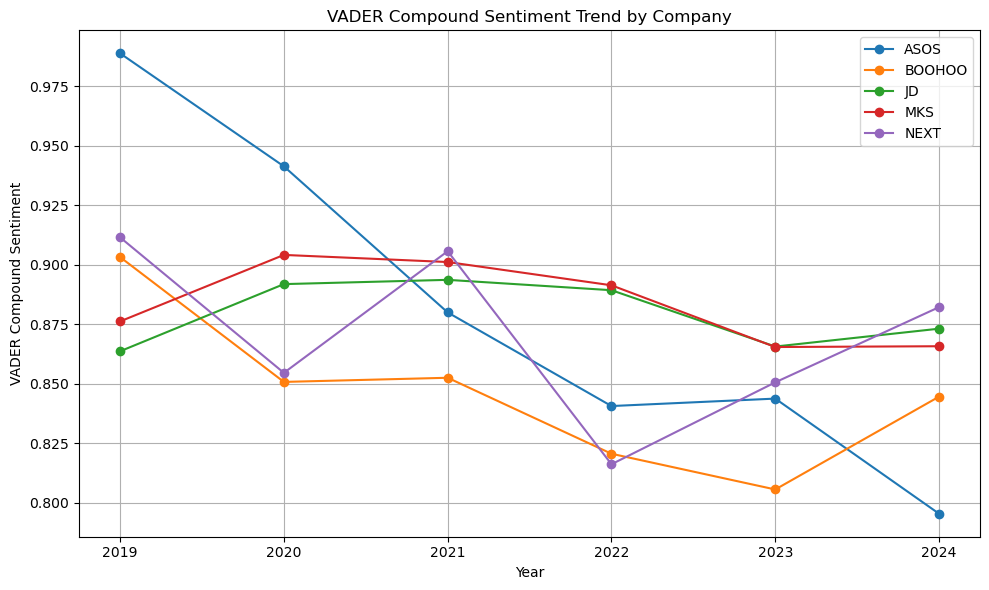

In [86]:
# VADER Sentiment Trend Over Time

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for company in final_analysis_df["company_short"].unique():
    company_data = final_analysis_df[final_analysis_df["company_short"] == company]
    plt.plot(
        company_data["year"],
        company_data["vader_compound"],
        marker="o",
        label=company
    )

plt.title("VADER Compound Sentiment Trend by Company")
plt.xlabel("Year")
plt.ylabel("VADER Compound Sentiment")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(output_dir / "vader_sentiment_trend_by_company.png", dpi=300)
plt.show()

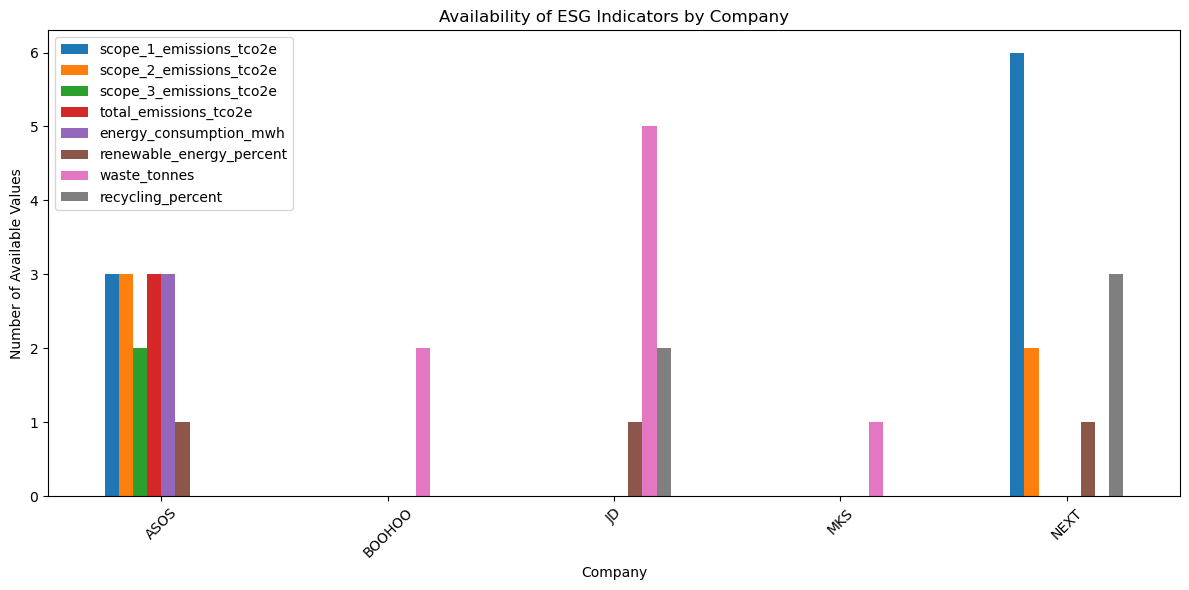

In [87]:
# ESG Data Availability by Company

esg_availability_by_company.plot(kind="bar", figsize=(12, 6))

plt.title("Availability of ESG Indicators by Company")
plt.xlabel("Company")
plt.ylabel("Number of Available Values")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(output_dir / "esg_data_availability_by_company.png", dpi=300)
plt.show()

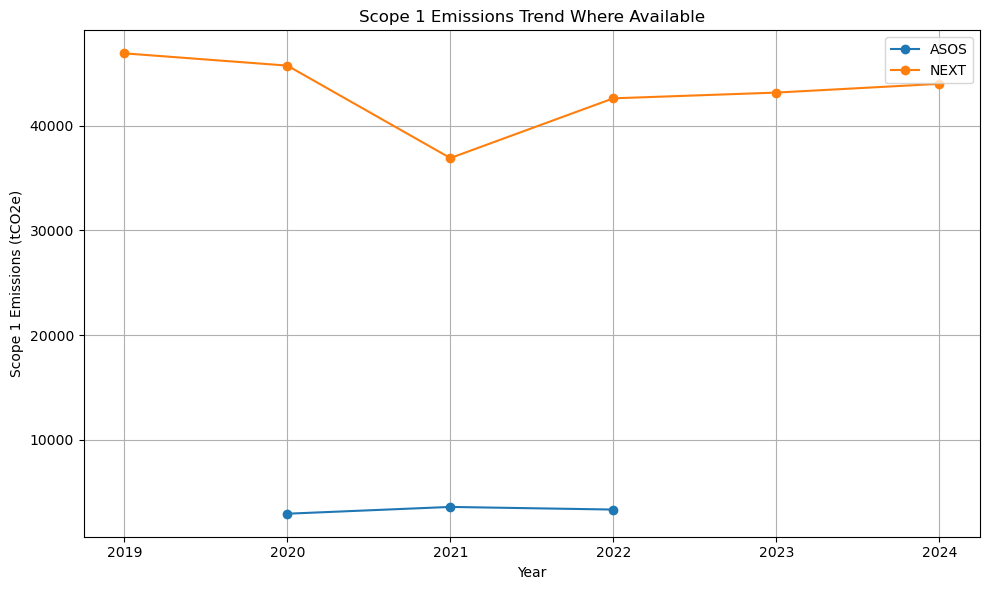

In [88]:
# Scope 1 Emissions Trend Where Available

plt.figure(figsize=(10, 6))

for company in final_analysis_df["company_short"].unique():
    company_data = final_analysis_df[
        (final_analysis_df["company_short"] == company) &
        (final_analysis_df["scope_1_emissions_tco2e"].notna())
    ]
    
    if not company_data.empty:
        plt.plot(
            company_data["year"],
            company_data["scope_1_emissions_tco2e"],
            marker="o",
            label=company
        )

plt.title("Scope 1 Emissions Trend Where Available")
plt.xlabel("Year")
plt.ylabel("Scope 1 Emissions (tCO2e)")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(output_dir / "scope_1_emissions_trend.png", dpi=300)
plt.show()

# 10. Exploratory Correlation Analysis

This section examines exploratory correlations between disclosure sentiment and available ESG/environmental performance indicators. Because ESG data availability is incomplete, the results are interpreted cautiously and used to identify indicative patterns rather than prove causal relationships.

In [89]:
# Correlation Analysis: VADER Sentiment vs ESG Indicators

import pandas as pd
from scipy.stats import spearmanr, pearsonr

# ESG variables to test
esg_variables = [
    "scope_1_emissions_tco2e",
    "scope_2_emissions_tco2e",
    "scope_3_emissions_tco2e",
    "total_emissions_tco2e",
    "energy_consumption_mwh",
    "renewable_energy_percent",
    "waste_tonnes",
    "recycling_percent"
]

correlation_results = []

for esg_var in esg_variables:
    
    # Keep only rows where both VADER and ESG value exist
    temp_df = final_analysis_df[["vader_compound", esg_var]].dropna()
    
    n = temp_df.shape[0]
    
    # Only run correlation if at least 3 observations exist
    if n >= 3:
        pearson_corr, pearson_p = pearsonr(temp_df["vader_compound"], temp_df[esg_var])
        spearman_corr, spearman_p = spearmanr(temp_df["vader_compound"], temp_df[esg_var])
        
        correlation_results.append({
            "esg_variable": esg_var,
            "observations": n,
            "pearson_correlation": pearson_corr,
            "pearson_p_value": pearson_p,
            "spearman_correlation": spearman_corr,
            "spearman_p_value": spearman_p
        })
    else:
        correlation_results.append({
            "esg_variable": esg_var,
            "observations": n,
            "pearson_correlation": None,
            "pearson_p_value": None,
            "spearman_correlation": None,
            "spearman_p_value": None
        })

correlation_results_df = pd.DataFrame(correlation_results)

# Save output
correlation_results_df.to_csv(
    output_dir / "vader_esg_correlation_results.csv",
    index=False
)

correlation_results_df

,esg_variable,observations,pearson_correlation,pearson_p_value,spearman_correlation,spearman_p_value
0,scope_1_emissions_tco2e,9,-0.230653,0.550453,0.000000,1.000000
1,scope_2_emissions_tco2e,5,-0.001570,0.998002,-0.300000,0.623838
2,scope_3_emissions_tco2e,2,NaN,NaN,NaN,NaN
3,total_emissions_tco2e,3,0.966728,0.164682,1.000000,0.000000
4,energy_consumption_mwh,3,-0.999978,0.004215,-1.000000,0.000000
5,renewable_energy_percent,3,-0.353524,0.769966,-0.500000,0.666667
6,waste_tonnes,8,0.257292,0.538445,0.095238,0.822505
7,recycling_percent,5,0.695653,0.192085,0.872082,0.053854


The correlation analysis shows mixed and mostly statistically insignificant relationships between disclosure sentiment and environmental performance indicators. This suggests that positive sustainability language alone does not consistently align with measurable environmental performance across the selected UK fashion retailers. However, the analysis is exploratory because ESG data availability was inconsistent across companies and years.

# 11. Visualising VADER and ESG Relationships

This section visualises selected relationships between VADER compound sentiment and available ESG indicators. Scatter plots are used to support the exploratory interpretation of the correlation results.

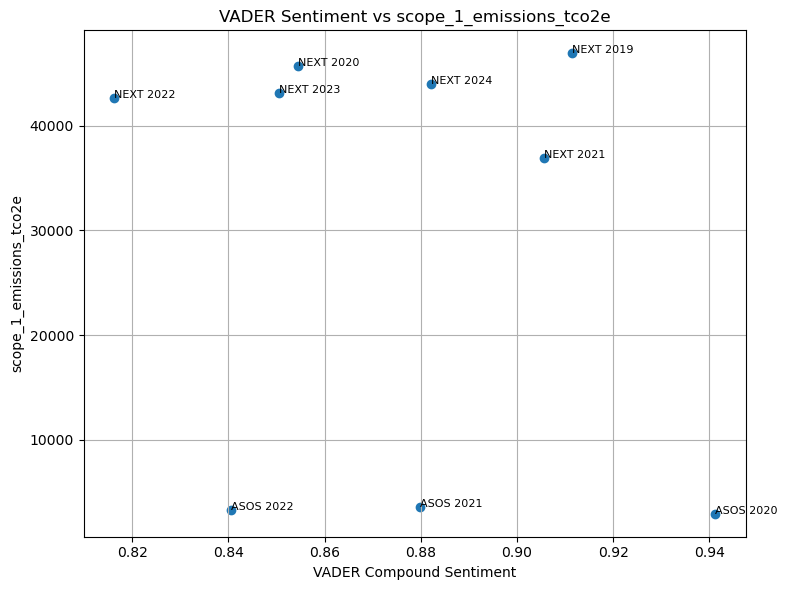

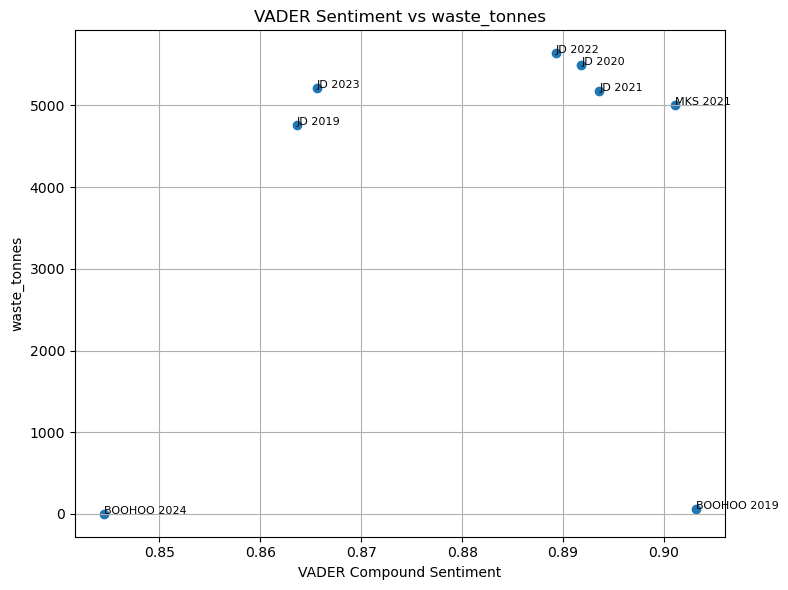

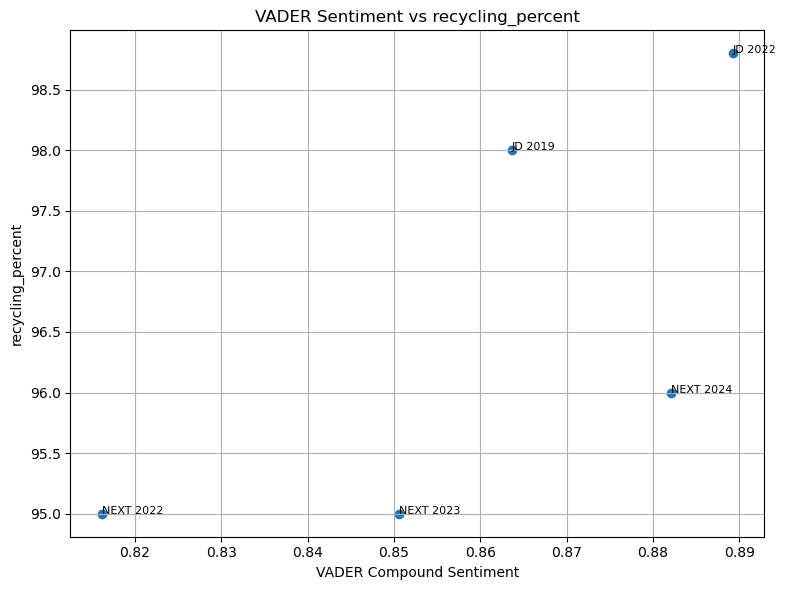

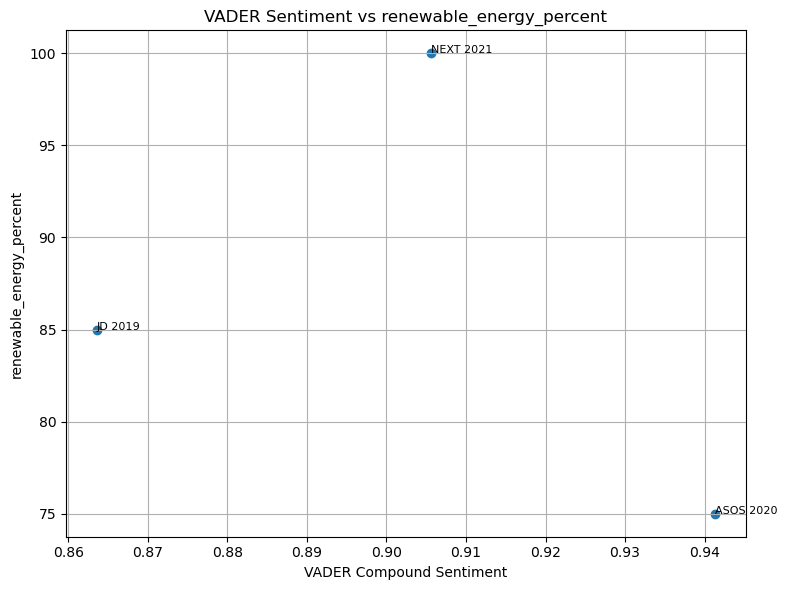

In [90]:
# Scatter Plots: VADER Sentiment vs ESG Indicators

import matplotlib.pyplot as plt

selected_esg_vars = [
    "scope_1_emissions_tco2e",
    "waste_tonnes",
    "recycling_percent",
    "renewable_energy_percent"
]

for esg_var in selected_esg_vars:
    
    plot_df = final_analysis_df[["company_short", "year", "vader_compound", esg_var]].dropna()
    
    if plot_df.shape[0] >= 3:
        plt.figure(figsize=(8, 6))
        plt.scatter(plot_df["vader_compound"], plot_df[esg_var])
        
        for _, row in plot_df.iterrows():
            plt.text(
                row["vader_compound"],
                row[esg_var],
                f"{row['company_short']} {int(row['year'])}",
                fontsize=8
            )
        
        plt.title(f"VADER Sentiment vs {esg_var}")
        plt.xlabel("VADER Compound Sentiment")
        plt.ylabel(esg_var)
        plt.grid(True)
        plt.tight_layout()
        
        plt.savefig(output_dir / f"vader_vs_{esg_var}.png", dpi=300)
        plt.show()

# 12. BERTopic Topic Interpretation

This section reviews the topics generated by BERTopic and identifies which topics are related to sustainability, environmental performance or ESG disclosure. These topics are then used to examine how much attention each company gives to ESG-related themes in its annual reports.

In [91]:
# Load BERTopic Topic Labels for Review

import pandas as pd
from pathlib import Path

base_dir = Path.cwd().parent
output_dir = base_dir / "05_outputs"

# Load topic label review file
topic_labels_df = pd.read_csv(output_dir / "bertopic_topic_labels_for_review.csv")

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", None)

topic_labels_df.head(70)

,topic_id,top_10_words,manual_topic_label,is_environmental_or_esg_topic,is_possible_esg_topic
0,0,"remuneration, performance, executive, committee, bonus, salary, directors, executive directors, awards, pay",NaN,NaN,No
1,1,"impairment, assets, million, value, group, assumptions, acquisition, goodwill, period, cash",NaN,NaN,No
2,2,"company, shares, resolution, authority, ordinary, agm, directors, share, ordinary shares, securities",NaN,NaN,No
3,3,"hedging, hedge, foreign, currency, hedged, fair value, fair, rate, value, hedges",NaN,NaN,No
4,4,"lease, leases, right use, payments, asset, right, lease liability, use, lease payments, liability",NaN,NaN,No
5,5,"sales, online, margin, jan, year, growth, price sales, customers, costs, total",NaN,NaN,No
6,6,"stores, jd, sports, fashion, sports fashion, store, million, group, period, new",NaN,NaN,No
7,7,"risk, risks, internal, committee, management, business, controls, audit, risk management, internal audit",NaN,NaN,No
8,8,"tax, deferred tax, deferred, income, share, recognised, shares, assets, ordinary, taxable",NaN,NaN,No
9,9,"board, committee, executive, directors, non executive, meetings, director, chairman, non, senior",NaN,NaN,No


## Manual BERTopic labelling step

Open `bertopic_topic_labels_for_review.csv` in Excel. For each topic, write a clear manual label and mark whether it is ESG-related using `Yes` or `No`.

After checking all topics, save the finished reviewed file as:

`bertopic_topic_labels_reviewed.csv`

The later analysis uses only the topics marked `Yes` to calculate ESG topic proportion.


# 13. Calculating ESG Topic Proportion

This section uses the manually reviewed BERTopic labels to calculate the proportion of ESG-related topics in each company-year report. This helps assess whether companies give more or less attention to ESG-related disclosure themes over time.

In [107]:
# Calculate ESG Topic Proportion by Company-Year

import pandas as pd
from pathlib import Path

base_dir = Path.cwd().parent
output_dir = base_dir / "05_outputs"

# Load reviewed topic labels.
# Preferred file name is bertopic_topic_labels_reviewed.csv.
# If that file is not found, the code uses bertopic_topic_labels_for_review.csv as a backup.

reviewed_topic_path = output_dir / "bertopic_topic_labels_reviewed.csv"
backup_topic_path = output_dir / "bertopic_topic_labels_for_review.csv"

if reviewed_topic_path.exists():
    topic_labels_reviewed_df = pd.read_csv(reviewed_topic_path)
    print("Loaded reviewed topic labels:", reviewed_topic_path.name)
else:
    topic_labels_reviewed_df = pd.read_csv(backup_topic_path)
    print("Loaded backup topic labels:", backup_topic_path.name)

# Clean Yes/No column
topic_labels_reviewed_df["is_possible_esg_topic"] = (
    topic_labels_reviewed_df["is_possible_esg_topic"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Get ESG-related topic IDs
esg_topic_ids = topic_labels_reviewed_df[
    topic_labels_reviewed_df["is_possible_esg_topic"] == "yes"
]["topic_id"].tolist()

print("ESG topic IDs:", esg_topic_ids)
print("Number of ESG topics:", len(esg_topic_ids))

# Load BERTopic chunk-level results
bertopic_chunks_df = pd.read_csv(output_dir / "bertopic_chunk_level_results.csv")

# Remove outlier topic -1
valid_chunks_df = bertopic_chunks_df[bertopic_chunks_df["bertopic_topic"] != -1].copy()

# Mark whether each chunk is ESG-related
valid_chunks_df["is_esg_topic"] = valid_chunks_df["bertopic_topic"].isin(esg_topic_ids)

# Calculate ESG topic proportion by company-year
esg_topic_summary = valid_chunks_df.groupby(["company_short", "year"]).agg(
    total_valid_chunks=("bertopic_topic", "count"),
    esg_topic_chunks=("is_esg_topic", "sum")
).reset_index()

esg_topic_summary["esg_topic_proportion"] = (
    esg_topic_summary["esg_topic_chunks"] / esg_topic_summary["total_valid_chunks"]
)

# Save output
esg_topic_summary.to_csv(
    output_dir / "esg_topic_proportion_by_company_year.csv",
    index=False
)

print("ESG topic proportion file saved.")
esg_topic_summary.head(30)

Loaded backup topic labels: bertopic_topic_labels_for_review.csv
ESG topic IDs: [10.0, 11.0, 12.0, 16.0, 20.0, 38.0, 43.0, 45.0, 50.0, 52.0, 57.0, 59.0]
Number of ESG topics: 12
ESG topic proportion file saved.


,company_short,year,total_valid_chunks,esg_topic_chunks,esg_topic_proportion
0,ASOS,2019,69,4,0.057971
1,ASOS,2020,76,9,0.118421
2,ASOS,2021,90,8,0.088889
3,ASOS,2022,110,19,0.172727
4,ASOS,2023,117,26,0.222222
5,ASOS,2024,117,23,0.196581
6,BOOHOO,2019,43,4,0.093023
7,BOOHOO,2020,52,8,0.153846
8,BOOHOO,2021,54,7,0.129630
9,BOOHOO,2022,71,19,0.267606


# 14. Adding ESG Topic Proportion to Final Analysis Dataset

This section merges the BERTopic ESG topic proportion with the final NLP and ESG dataset. This creates one complete analysis dataset containing VADER sentiment, ESG topic attention and environmental performance indicators.

In [108]:
# Merge ESG Topic Proportion into Final Analysis Dataset

import pandas as pd
from pathlib import Path

base_dir = Path.cwd().parent
output_dir = base_dir / "05_outputs"

# Load final NLP + ESG dataset
final_analysis_df = pd.read_csv(output_dir / "final_nlp_esg_analysis_dataset.csv")

# Load ESG topic proportion dataset
esg_topic_summary = pd.read_csv(output_dir / "esg_topic_proportion_by_company_year.csv")

# Merge ESG topic proportion into final analysis dataset
final_analysis_df = final_analysis_df.merge(
    esg_topic_summary[[
        "company_short",
        "year",
        "total_valid_chunks",
        "esg_topic_chunks",
        "esg_topic_proportion"
    ]],
    on=["company_short", "year"],
    how="left"
)

# Save updated final dataset
final_analysis_df.to_csv(
    output_dir / "final_nlp_esg_analysis_dataset_with_topics.csv",
    index=False
)

print("Updated final analysis dataset saved.")
print("Shape:", final_analysis_df.shape)

final_analysis_df[[
    "company_short",
    "year",
    "vader_compound",
    "esg_topic_proportion",
    "scope_1_emissions_tco2e",
    "scope_2_emissions_tco2e",
    "total_emissions_tco2e"
]].head(30)

Updated final analysis dataset saved.
Shape: (30, 81)


,company_short,year,vader_compound,esg_topic_proportion,scope_1_emissions_tco2e,scope_2_emissions_tco2e,total_emissions_tco2e
0,ASOS,2019,0.988711,0.057971,NaN,NaN,236720.0
1,ASOS,2020,0.941258,0.118421,2955.0,11084.0,NaN
2,ASOS,2021,0.879921,0.088889,3602.0,11338.0,14958.0
3,ASOS,2022,0.840607,0.172727,3351.0,11497.0,14848.0
4,ASOS,2023,0.843732,0.222222,NaN,NaN,NaN
5,ASOS,2024,0.795398,0.196581,NaN,NaN,NaN
6,BOOHOO,2019,0.903150,0.093023,NaN,NaN,NaN
7,BOOHOO,2020,0.850739,0.153846,NaN,NaN,NaN
8,BOOHOO,2021,0.852482,0.129630,NaN,NaN,NaN
9,BOOHOO,2022,0.820577,0.267606,NaN,NaN,NaN


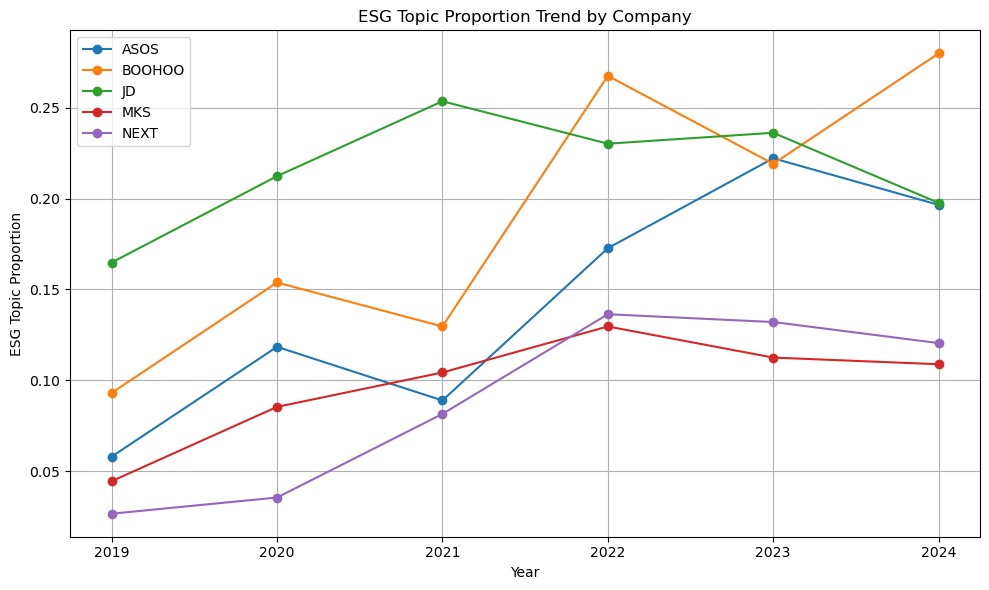

In [109]:
# ESG Topic Proportion Trend by Company

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for company in final_analysis_df["company_short"].unique():
    company_data = final_analysis_df[final_analysis_df["company_short"] == company]
    
    plt.plot(
        company_data["year"],
        company_data["esg_topic_proportion"],
        marker="o",
        label=company
    )

plt.title("ESG Topic Proportion Trend by Company")
plt.xlabel("Year")
plt.ylabel("ESG Topic Proportion")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(output_dir / "esg_topic_proportion_trend_by_company.png", dpi=300)
plt.show()

# 15. ESG Topic Proportion and Environmental Performance

This section examines whether the proportion of ESG-related topics identified by BERTopic is associated with available environmental performance indicators. This supports the second research question by exploring whether ESG topic attention aligns with measurable environmental performance.


In [110]:
# Correlation Analysis: ESG Topic Proportion vs ESG Indicators

from scipy.stats import pearsonr, spearmanr
import pandas as pd

esg_variables = [
    "scope_1_emissions_tco2e",
    "scope_2_emissions_tco2e",
    "scope_3_emissions_tco2e",
    "total_emissions_tco2e",
    "energy_consumption_mwh",
    "renewable_energy_percent",
    "waste_tonnes",
    "recycling_percent"
]

topic_correlation_results = []

for esg_var in esg_variables:
    
    temp_df = final_analysis_df[["esg_topic_proportion", esg_var]].dropna()
    n = temp_df.shape[0]
    
    if n >= 3:
        pearson_corr, pearson_p = pearsonr(
            temp_df["esg_topic_proportion"],
            temp_df[esg_var]
        )
        
        spearman_corr, spearman_p = spearmanr(
            temp_df["esg_topic_proportion"],
            temp_df[esg_var]
        )
        
        topic_correlation_results.append({
            "esg_variable": esg_var,
            "observations": n,
            "pearson_correlation": pearson_corr,
            "pearson_p_value": pearson_p,
            "spearman_correlation": spearman_corr,
            "spearman_p_value": spearman_p
        })
    else:
        topic_correlation_results.append({
            "esg_variable": esg_var,
            "observations": n,
            "pearson_correlation": None,
            "pearson_p_value": None,
            "spearman_correlation": None,
            "spearman_p_value": None
        })

topic_correlation_results_df = pd.DataFrame(topic_correlation_results)

topic_correlation_results_df.to_csv(
    output_dir / "esg_topic_proportion_correlation_results.csv",
    index=False
)

topic_correlation_results_df

,esg_variable,observations,pearson_correlation,pearson_p_value,spearman_correlation,spearman_p_value
0,scope_1_emissions_tco2e,9,-0.434516,0.242522,-0.483333,0.187470
1,scope_2_emissions_tco2e,5,-0.864796,0.058453,-0.700000,0.188120
2,scope_3_emissions_tco2e,2,NaN,NaN,NaN,NaN
3,total_emissions_tco2e,3,-0.708532,0.498716,-1.000000,0.000000
4,energy_consumption_mwh,3,0.542610,0.634872,0.500000,0.666667
5,renewable_energy_percent,3,-0.542179,0.635199,-0.500000,0.666667
6,waste_tonnes,8,0.130206,0.758610,0.095238,0.822505
7,recycling_percent,5,0.862207,0.060116,0.666886,0.218894


ESG topic proportion has mixed relationships with environmental performance indicators. Reports with more ESG-related topic coverage sometimes appear to have better environmental indicators, such as lower Scope 1/2 emissions or higher recycling percentages. However, because ESG performance data was incomplete, these findings should be interpreted as exploratory rather than conclusive.

# 16. Visualising ESG Topic Proportion and Environmental Performance

This section visualises selected relationships between BERTopic ESG topic proportion and environmental performance indicators. These plots help interpret whether greater ESG topic coverage appears to align with measurable ESG performance.

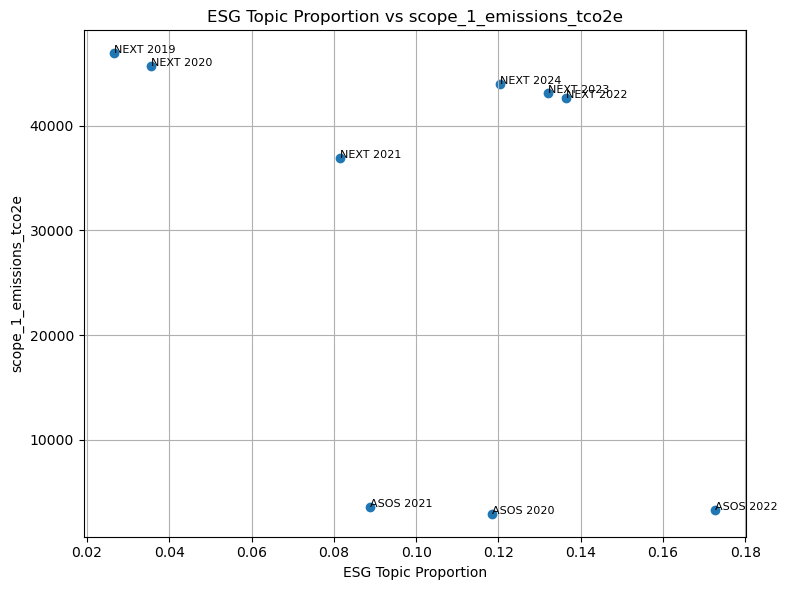

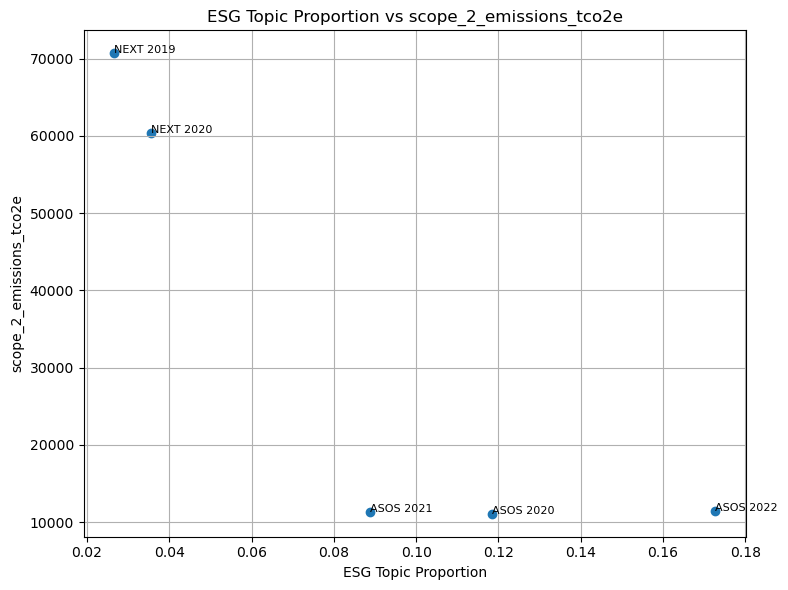

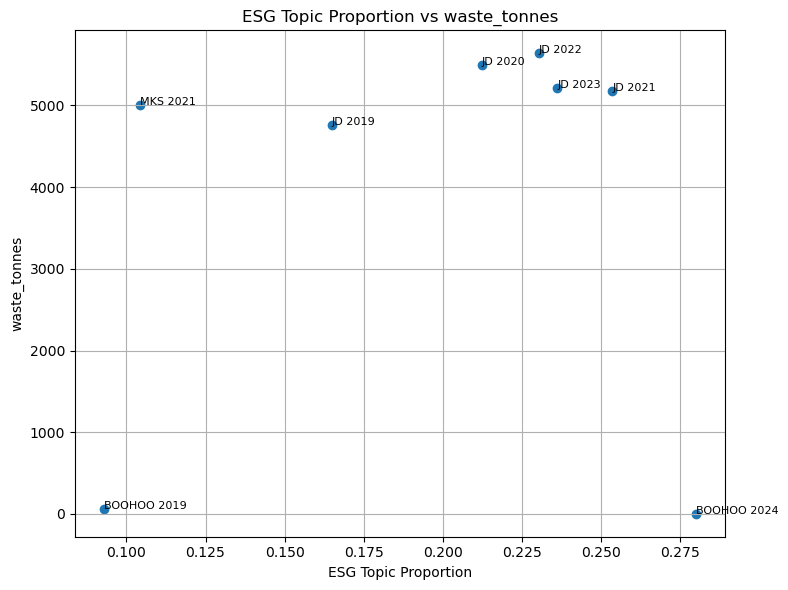

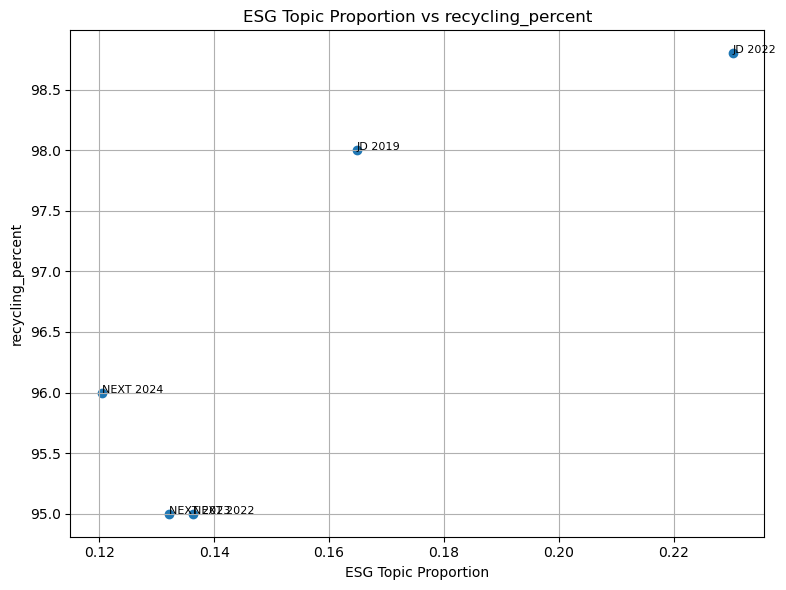

In [98]:
# Scatter Plots: ESG Topic Proportion vs ESG Indicators

import matplotlib.pyplot as plt

selected_esg_vars = [
    "scope_1_emissions_tco2e",
    "scope_2_emissions_tco2e",
    "waste_tonnes",
    "recycling_percent"
]

for esg_var in selected_esg_vars:
    
    plot_df = final_analysis_df[[
        "company_short",
        "year",
        "esg_topic_proportion",
        esg_var
    ]].dropna()
    
    if plot_df.shape[0] >= 3:
        plt.figure(figsize=(8, 6))
        plt.scatter(plot_df["esg_topic_proportion"], plot_df[esg_var])
        
        for _, row in plot_df.iterrows():
            plt.text(
                row["esg_topic_proportion"],
                row[esg_var],
                f"{row['company_short']} {int(row['year'])}",
                fontsize=8
            )
        
        plt.title(f"ESG Topic Proportion vs {esg_var}")
        plt.xlabel("ESG Topic Proportion")
        plt.ylabel(esg_var)
        plt.grid(True)
        plt.tight_layout()
        
        plt.savefig(output_dir / f"esg_topic_proportion_vs_{esg_var}.png", dpi=300)
        plt.show()

# 17. Exploratory Linear Regression Analysis

This section adds a simple linear regression test to examine whether ESG-related topic coverage is associated with report sentiment. The dependent variable is VADER compound sentiment, and the independent variable is ESG topic proportion. This test is exploratory because the dataset contains only 30 company-year observations.

In [115]:
# Exploratory Linear Regression: ESG Topic Proportion and VADER Sentiment

# This test checks whether reports with more ESG-related topic coverage also tend to have more positive disclosure sentiment.
# Dependent variable: VADER compound sentiment
# Independent variable: ESG topic proportion


from scipy.stats import linregress
import pandas as pd
import numpy as np

# Keep only rows where both variables are available
regression_df = final_analysis_df[[
    "company_short",
    "year",
    "vader_compound",
    "esg_topic_proportion"
]].dropna().copy()

# Run simple linear regression
reg_result = linregress(
    regression_df["esg_topic_proportion"],
    regression_df["vader_compound"]
)

# Create a clean regression results table
linear_regression_results = pd.DataFrame({
    "test": ["Linear regression"],
    "dependent_variable": ["vader_compound"],
    "independent_variable": ["esg_topic_proportion"],
    "observations": [regression_df.shape[0]],
    "intercept": [reg_result.intercept],
    "slope_coefficient": [reg_result.slope],
    "r_value": [reg_result.rvalue],
    "r_squared": [reg_result.rvalue ** 2],
    "p_value": [reg_result.pvalue],
    "standard_error": [reg_result.stderr]
})

# Save results
linear_regression_results.to_csv(
    output_dir / "linear_regression_results.csv",
    index=False
)

linear_regression_results

,test,dependent_variable,independent_variable,observations,intercept,slope_coefficient,r_value,r_squared,p_value,standard_error
0,Linear regression,vader_compound,esg_topic_proportion,30,0.911648,-0.267772,-0.47755,0.228054,0.007614,0.093103


## Linear Regression Interpretation

The linear regression examines whether ESG topic coverage predicts VADER compound sentiment. Because the dataset contains 30 company-year observations, the regression is treated as exploratory. A statistically significant p-value would suggest that ESG topic coverage is associated with sentiment positivity. However, this result should not be interpreted causally because the analysis is based on annual report disclosures rather than independent ESG verification data.

# 18. Mann-Whitney U Test

This section uses a Mann-Whitney U test to compare VADER compound sentiment between reports with lower ESG topic coverage and reports with higher ESG topic coverage. This non-parametric test is suitable because the sample is small and does not assume normal distribution.

In [116]:
# Mann-Whitney U Test: Low vs High ESG Topic Coverage

# This test compares VADER sentiment between two groups:
# 1. Reports with low ESG topic proportion
# 2. Reports with high ESG topic proportion
# The median ESG topic proportion is used to split the reports into groups.

from scipy.stats import mannwhitneyu
import pandas as pd
import numpy as np

# Keep only rows where both variables are available
mw_df = final_analysis_df[[
    "company_short",
    "year",
    "vader_compound",
    "esg_topic_proportion"
]].dropna().copy()

# Create high and low ESG topic coverage groups using the median
median_esg_topic_proportion = mw_df["esg_topic_proportion"].median()

mw_df["esg_topic_group"] = np.where(
    mw_df["esg_topic_proportion"] >= median_esg_topic_proportion,
    "High ESG topic coverage",
    "Low ESG topic coverage"
)

# Split VADER scores into two groups
low_group = mw_df[mw_df["esg_topic_group"] == "Low ESG topic coverage"]["vader_compound"]
high_group = mw_df[mw_df["esg_topic_group"] == "High ESG topic coverage"]["vader_compound"]

# Run Mann-Whitney U test
u_statistic, p_value = mannwhitneyu(
    low_group,
    high_group,
    alternative="two-sided"
)

# Create summary table
mann_whitney_results = pd.DataFrame({
    "test": ["Mann-Whitney U test"],
    "grouping_variable": ["esg_topic_proportion"],
    "comparison_variable": ["vader_compound"],
    "group_1": ["Low ESG topic coverage"],
    "group_1_observations": [low_group.shape[0]],
    "group_1_median_vader": [low_group.median()],
    "group_2": ["High ESG topic coverage"],
    "group_2_observations": [high_group.shape[0]],
    "group_2_median_vader": [high_group.median()],
    "u_statistic": [u_statistic],
    "p_value": [p_value]
})

# Save results
mann_whitney_results.to_csv(
    output_dir / "mann_whitney_u_test_results.csv",
    index=False
)

mann_whitney_results

,test,grouping_variable,comparison_variable,group_1,group_1_observations,group_1_median_vader,group_2,group_2_observations,group_2_median_vader,u_statistic,p_value
0,Mann-Whitney U test,esg_topic_proportion,vader_compound,Low ESG topic coverage,15,0.891311,High ESG topic coverage,15,0.850564,193.0,0.000906


## Mann-Whitney U Test Interpretation

The Mann-Whitney U test compares whether reports with higher ESG topic coverage have significantly different VADER sentiment from reports with lower ESG topic coverage. The result should be interpreted cautiously because the test compares disclosure patterns within a small sample of 30 annual reports. A non-significant result would suggest that higher ESG topic coverage does not necessarily mean a report uses more positive sentiment.

# 19. Summary of Main Findings

This section summarises the main findings from VADER sentiment analysis, BERTopic ESG topic modelling and ESG performance comparison. The table is designed to support the dissertation findings chapter.

In [117]:
# ============================================================
# Create Cautious Summary of Main Findings
# ============================================================

findings_summary = pd.DataFrame({
    "finding_area": [
        "VADER sentiment",
        "ESG topic proportion",
        "ESG data availability",
        "VADER vs ESG performance",
        "BERTopic ESG topics vs ESG performance",
        "Linear regression",
        "Mann-Whitney U test",
        "Overall greenwashing-risk interpretation"
    ],
    
    "main_finding": [
        "Annual reports generally show positive VADER compound sentiment across companies and years.",
        
        "BERTopic results show that ESG-related topic coverage generally increased between 2019 and 2024, although the pattern differs by company.",
        
        "Environmental performance data was inconsistently disclosed across companies and years. Data availability was stronger for ASOS, NEXT and JD than for BOOHOO and MKS.",
        
        "Correlation results between VADER sentiment and ESG indicators were mixed and mostly statistically insignificant. These results should be treated as exploratory rather than conclusive.",
        
        "ESG topic proportion showed some tentative relationships with selected ESG indicators, such as emissions and recycling. However, several tests were based on limited observations and should not be treated as statistically conclusive.",
        
        "The linear regression tested whether ESG topic proportion was associated with VADER compound sentiment. This provides an exploratory check of whether ESG topic coverage and sentiment positivity move together.",
        
        "The Mann-Whitney U test compared VADER sentiment between reports with low and high ESG topic coverage. This provides a non-parametric comparison of sentiment differences between disclosure groups.",
        
        "The findings suggest possible greenwashing-risk indicators where positive language or increased ESG topic coverage is not clearly matched by consistent quantitative environmental performance evidence."
    ],
    
    "interpretation_for_dissertation": [
        "Positive sustainability language is common in annual reports, but positivity alone cannot confirm strong ESG performance.",
        
        "BERTopic provides quantitative evidence of changing ESG disclosure attention over time, but this should be interpreted as topic coverage rather than proof of sustainability performance.",
        
        "Inconsistent ESG disclosure is itself an important finding because it limits comparability between companies and years.",
        
        "The study does not prove greenwashing. It shows that sentiment positivity is not consistently aligned with available company-disclosed environmental indicators.",
        
        "Topic modelling supports RQ2 by showing how ESG attention varies. However, relationships with performance indicators are indicative only because some variables have small sample sizes.",
        
        "The regression result should be interpreted as exploratory and not causal, because it is based on annual report disclosures and a small company-year sample.",
        
        "The Mann-Whitney result supports the comparison of high and low ESG-topic disclosure groups, but it should not be treated as definitive evidence of greenwashing.",
        
        "The project identifies greenwashing-risk signals and disclosure-performance misalignment risks, rather than making definitive or legal claims of greenwashing."
    ]
})

findings_summary.to_csv(
    output_dir / "summary_of_main_findings.csv",
    index=False
)

findings_summary

,finding_area,main_finding,interpretation_for_dissertation
0,VADER sentiment,Annual reports generally show positive VADER compound sentiment across companies and years.,"Positive sustainability language is common in annual reports, but positivity alone cannot confirm strong ESG performance."
1,ESG topic proportion,"BERTopic results show that ESG-related topic coverage generally increased between 2019 and 2024, although the pattern differs by company.","BERTopic provides quantitative evidence of changing ESG disclosure attention over time, but this should be interpreted as topic coverage rather than proof of sustainability performance."
2,ESG data availability,"Environmental performance data was inconsistently disclosed across companies and years. Data availability was stronger for ASOS, NEXT and JD than for BOOHOO and MKS.",Inconsistent ESG disclosure is itself an important finding because it limits comparability between companies and years.
3,VADER vs ESG performance,Correlation results between VADER sentiment and ESG indicators were mixed and mostly statistically insignificant. These results should be treated as exploratory rather than conclusive.,The study does not prove greenwashing. It shows that sentiment positivity is not consistently aligned with available company-disclosed environmental indicators.
4,BERTopic ESG topics vs ESG performance,"ESG topic proportion showed some tentative relationships with selected ESG indicators, such as emissions and recycling. However, several tests were based on limited observations and should not be treated as statistically conclusive.","Topic modelling supports RQ2 by showing how ESG attention varies. However, relationships with performance indicators are indicative only because some variables have small sample sizes."
5,Linear regression,The linear regression tested whether ESG topic proportion was associated with VADER compound sentiment. This provides an exploratory check of whether ESG topic coverage and sentiment positivity move together.,"The regression result should be interpreted as exploratory and not causal, because it is based on annual report disclosures and a small company-year sample."
6,Mann-Whitney U test,The Mann-Whitney U test compared VADER sentiment between reports with low and high ESG topic coverage. This provides a non-parametric comparison of sentiment differences between disclosure groups.,"The Mann-Whitney result supports the comparison of high and low ESG-topic disclosure groups, but it should not be treated as definitive evidence of greenwashing."
7,Overall greenwashing-risk interpretation,The findings suggest possible greenwashing-risk indicators where positive language or increased ESG topic coverage is not clearly matched by consistent quantitative environmental performance evidence.,"The project identifies greenwashing-risk signals and disclosure-performance misalignment risks, rather than making definitive or legal claims of greenwashing."


In [118]:
# Final Output Files Check

important_outputs = [
    "main_text_dataset_cleaned.csv",
    "vader_sentiment_summary.csv",
    "bertopic_topic_info.csv",
    "bertopic_topic_proportions_long.csv",
    "bertopic_chunk_level_results.csv",
    "esg_topic_proportion_by_company_year.csv",
    "final_company_year_esg_dataset.csv",
    "final_nlp_esg_analysis_dataset.csv",
    "final_nlp_esg_analysis_dataset_with_topics.csv",
    "descriptive_statistics_nlp_esg.csv",
    "esg_availability_by_company.csv",
    "vader_esg_correlation_results.csv",
    "esg_topic_proportion_correlation_results.csv",
    "linear_regression_results.csv",
    "mann_whitney_u_test_results.csv",
    "summary_of_main_findings.csv",
    "vader_sentiment_trend_by_company.png",
    "esg_data_availability_by_company.png",
    "scope_1_emissions_trend.png",
    "esg_topic_proportion_trend_by_company.png"
]

for file in important_outputs:
    file_path = output_dir / file
    print(file, "->", "FOUND" if file_path.exists() else "MISSING")

main_text_dataset_cleaned.csv -> FOUND
vader_sentiment_summary.csv -> FOUND
bertopic_topic_info.csv -> FOUND
bertopic_topic_proportions_long.csv -> FOUND
bertopic_chunk_level_results.csv -> FOUND
esg_topic_proportion_by_company_year.csv -> FOUND
final_company_year_esg_dataset.csv -> FOUND
final_nlp_esg_analysis_dataset.csv -> FOUND
final_nlp_esg_analysis_dataset_with_topics.csv -> FOUND
descriptive_statistics_nlp_esg.csv -> FOUND
esg_availability_by_company.csv -> FOUND
vader_esg_correlation_results.csv -> FOUND
esg_topic_proportion_correlation_results.csv -> FOUND
linear_regression_results.csv -> FOUND
mann_whitney_u_test_results.csv -> FOUND
summary_of_main_findings.csv -> FOUND
vader_sentiment_trend_by_company.png -> FOUND
esg_data_availability_by_company.png -> FOUND
scope_1_emissions_trend.png -> FOUND
esg_topic_proportion_trend_by_company.png -> FOUND


# 20. Final Methodological Note

The analysis is based on 30 annual reports from five UK fashion retail companies between 2019 and 2024. VADER was used to measure disclosure sentiment, while BERTopic was used to identify ESG-related disclosure themes. ESG performance indicators were manually extracted from annual report snippets where available. Because ESG data availability was inconsistent across companies and years, the statistical analysis is exploratory and does not claim to prove greenwashing. Instead, the results identify potential greenwashing-risk indicators where positive language or ESG topic emphasis is not consistently supported by comparable environmental performance evidence.

In [119]:
# ============================================================
# Save Final Notebook Completion Marker
# ============================================================

completion_note = """
Final analysis completed.

This notebook includes:
1. PDF text extraction and cleaning
2. VADER sentiment analysis
3. BERTopic topic modelling
4. Manual ESG data extraction support
5. Final ESG company-year dataset
6. Merged NLP + ESG analysis dataset
7. Descriptive statistics
8. VADER vs ESG correlation analysis
9. ESG topic proportion analysis
10. ESG topic proportion vs ESG indicator correlation analysis
11. Exploratory linear regression analysis
12. Mann-Whitney U test
13. Visual analysis of sentiment, ESG topic coverage and ESG indicators
14. Cautious summary of main findings

Important methodological note:
The ESG indicators used in this notebook are company-disclosed quantitative environmental indicators extracted from annual reports. They are not independent third-party ESG ratings. Therefore, the analysis compares narrative disclosure language and topic coverage with company-reported environmental indicators.

The analysis is exploratory because ESG data availability is incomplete and inconsistent across companies and years. The findings should be interpreted as potential greenwashing-risk indicators and disclosure-performance misalignment signals, not as proof of greenwashing.
"""

with open(output_dir / "analysis_completion_note.txt", "w", encoding="utf-8") as f:
    f.write(completion_note)

print("Final analysis completion note saved.")

Final analysis completion note saved.
